# GWAS + Random Forest Pipeline
## Gallstone Disease SNP Analysis

**Workflow:**
1. Load professor's top-SNP list (`summary_results_sorted_by_p.csv`)
2. Load per-gene `.raw` files — only the top-SNP columns
3. Load phenotype from `Merged file with metabolites.xlsx`
4. Merge on IID
5. EDA plots
6. Single-SNP association statistics
7. Random Forest classification
8. Results summary

Packages ready
 Cases: 172 | Controls: 1032
 SNPs: 479
  CDHR3_region.raw: 36 SNPs loaded
  CLDN7_region.raw: 41 SNPs loaded
  CPZ_region.raw: 51 SNPs loaded
  ERICH1_region.raw: 42 SNPs loaded
  EXOC4_region.raw: 39 SNPs loaded
  GALNTL6_region.raw: 44 SNPs loaded
  GPC6_region.raw: 33 SNPs loaded
  GPRIN3_region.raw: 13 SNPs loaded
  HLA-G_region.raw: 19 SNPs loaded
  HMGB1P5_region.raw: 16 SNPs loaded
  LINC01122_region.raw: 10 SNPs loaded
  LRP8_region.raw: 13 SNPs loaded
  LUZP2_region.raw: 16 SNPs loaded
  MATN2_region.raw: 11 SNPs loaded
  OSBPL10_region.raw: 18 SNPs loaded
  PALM2AKAP2_region.raw: 8 SNPs loaded
  PTPRN2_region.raw: 14 SNPs loaded
  RNFT2_region.raw: 19 SNPs loaded
  RPL31P35_region.raw: 10 SNPs loaded
  TJP1_region.raw: 9 SNPs loaded
  UGGT1_region.raw: 17 SNPs loaded
Genotype: (1204, 480)
 Phenotype: 1197 | Cases: 170 | Controls: 1027
 Merged: (1197, 487) | Features: 483
SMOTE done | Train Cases: 821 Controls: 821

Training: RF — SNPs only ...
 CV AUC: 0.5219 

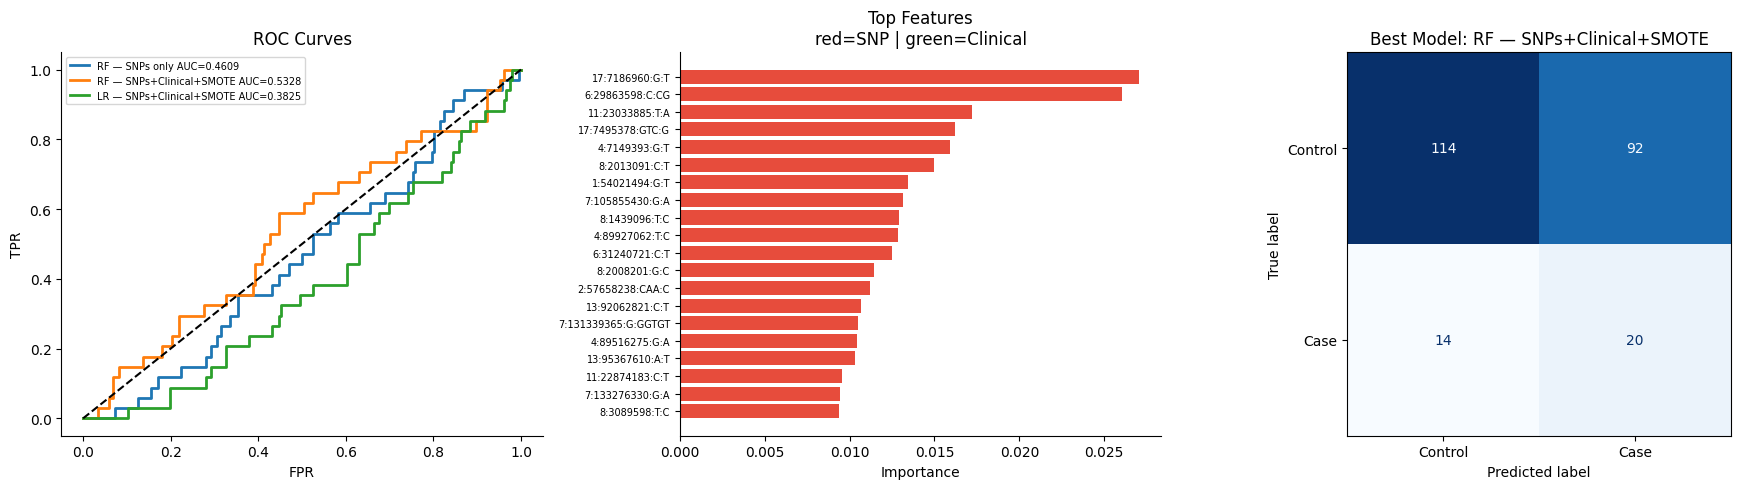


   COMPLETE


,Model,CV_AUC,CV_AUC_std,Test_AUC
0,RF — SNPs only,0.5219,0.0378,0.4609
1,RF — SNPs+Clinical+SMOTE,0.9738,0.0065,0.5328
2,LR — SNPs+Clinical+SMOTE,0.9113,0.0101,0.3825


In [1]:
import os, warnings, sys, subprocess
from pathlib import Path

for pkg in ['pandas','numpy','scipy','scikit-learn','matplotlib','seaborn','openpyxl','imbalanced-learn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'])
print('Packages ready')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
warnings.filterwarnings('ignore')
%matplotlib inline

# ── CONFIG ────────────────────────────────────────────────────────────────────
BASE       = Path(os.getcwd())
OUT        = BASE / 'gwas_output'
OUT.mkdir(exist_ok=True)
SNP_CSV    = BASE / 'summary_results sorted by p (1).csv'
PHENO_XLSX = BASE / 'Merged file with metabolites.xlsx'
CASES_TXT  = BASE / 'ID_gsd_172cases.txt'
CTRLS_TXT  = BASE / 'ID_gsd_1032controls.txt'

# ── STEP 1: Matched IDs ───────────────────────────────────────────────────────
cases_ids = pd.read_csv(CASES_TXT, sep=' ', dtype=str)
ctrl_ids  = pd.read_csv(CTRLS_TXT, sep=' ', dtype=str)
case_iids = cases_ids['IID'].str.strip().tolist()
ctrl_iids = ctrl_ids['IID'].str.strip().tolist()
all_selected_iids = set(case_iids + ctrl_iids)
print(f' Cases: {len(case_iids)} | Controls: {len(ctrl_iids)}')

# ── STEP 2: SNPs ──────────────────────────────────────────────────────────────
snp_raw = pd.read_csv(SNP_CSV)
snp_raw = snp_raw[snp_raw['MinP'] <= 1e-5]
snp_df  = (snp_raw[['Gene','TopSNP','MinP']]
           .sort_values('MinP')
           .drop_duplicates(subset='TopSNP')
           .reset_index(drop=True))
print(f' SNPs: {len(snp_df)}')

# ── STEP 3: Genotype ──────────────────────────────────────────────────────────
def load_raw(raw_path, snp_list):
    header  = pd.read_csv(raw_path, sep=r'\s+', nrows=0)
    snp_set = set(snp_list)
    col_map = {c: c.rsplit('_',1)[0] for c in header.columns
               if c.rsplit('_',1)[0] in snp_set}
    if not col_map:
        return pd.DataFrame()
    df = pd.read_csv(raw_path, sep=r'\s+',
                     usecols=['IID']+list(col_map), low_memory=False)
    df.rename(columns=col_map, inplace=True)
    df['IID'] = df['IID'].astype(str)
    print(f'  {raw_path.name}: {len(col_map)} SNPs loaded')
    return df

raw_files = sorted(BASE.glob('*_region.raw'))
gene_map  = {f.stem.replace('_region','').strip('_').upper(): f for f in raw_files}
gene_snps = snp_df.groupby('Gene')['TopSNP'].apply(list).to_dict()

frames = []
for gene, snps in gene_snps.items():
    g    = gene.upper().strip()
    path = gene_map.get(g)
    if path is None:
        matches = [k for k in gene_map if k.startswith(g) or g.startswith(k)]
        path = gene_map[matches[0]] if matches else None
    if path is None:
        print(f'WARNING: no .raw for {gene}')
        continue
    chunk = load_raw(path, snps)
    if not chunk.empty:
        frames.append(chunk)

geno = frames[0]
for f in frames[1:]:
    geno = pd.merge(geno, f, on='IID', how='outer')
geno          = geno.loc[:, ~geno.columns.duplicated()]
geno_filtered = geno[geno['IID'].isin(all_selected_iids)].copy()
print(f'Genotype: {geno_filtered.shape}')

# ── STEP 4: Phenotype + clinical ──────────────────────────────────────────────
pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno = pheno.apply(lambda col: col.map(
    lambda x: x.strip() if isinstance(x, str) else x))
pheno.columns  = pheno.columns.str.replace('\n',' ').str.strip()
pheno          = pheno.rename(columns={'IID2':'IID_match'})

clinical_search = ['age at consent','Gender','BMI','HEMOGLOBIN A1c']
available_clin  = []
for col in clinical_search:
    match = [c for c in pheno.columns if col.lower() in c.lower()]
    if match:
        available_clin.append(match[0])

if 'Gender' in available_clin:
    pheno['Gender'] = LabelEncoder().fit_transform(pheno['Gender'].fillna('Unknown'))
for col in available_clin:
    pheno[col] = pd.to_numeric(pheno[col], errors='coerce')

pheno = pheno[pheno['IID_match'].isin(all_selected_iids)].copy()
pheno['gall']      = pheno['gall'].str.lower()
pheno              = pheno[pheno['gall'].isin({'yes','no'})].copy()
pheno['label']     = (pheno['gall']=='yes').astype(int)
pheno['IID_match'] = pheno['IID_match'].astype(str)
print(f' Phenotype: {len(pheno)} | Cases: {pheno["label"].sum()} | Controls: {(pheno["label"]==0).sum()}')

# ── STEP 5: Merge ─────────────────────────────────────────────────────────────
merged = pd.merge(geno_filtered,
                  pheno[['IID_match','gall','label']+available_clin],
                  left_on='IID', right_on='IID_match', how='inner')
snp_cols     = [c for c in merged.columns if c in set(geno.columns)-{'IID'}]
all_features = snp_cols + available_clin
print(f' Merged: {merged.shape} | Features: {len(all_features)}')

# ── STEP 6: Features + SMOTE ──────────────────────────────────────────────────
X = SimpleImputer(strategy='median').fit_transform(
    merged[all_features].apply(pd.to_numeric, errors='coerce'))
y = merged['label'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

X_tr_sm, y_tr_sm = SMOTE(random_state=42, k_neighbors=5).fit_resample(X_tr, y_tr)
print(f'SMOTE done | Train Cases: {y_tr_sm.sum()} Controls: {(y_tr_sm==0).sum()}')

# ── STEP 7: Models — FAST settings ───────────────────────────────────────────
# n_estimators=100 and cv=3 to run fast
neg, pos = (y_tr==0).sum(), (y_tr==1).sum()

models = {
    'RF — SNPs only' : (
        RandomForestClassifier(
            n_estimators=100, max_depth=6,   # ← reduced for speed
            class_weight={0:1,1:neg/pos},
            random_state=42, n_jobs=-1),
        X_tr, y_tr),

    'RF — SNPs+Clinical+SMOTE' : (
        RandomForestClassifier(
            n_estimators=100, max_depth=6,   # ← reduced for speed
            random_state=42, n_jobs=-1),
        X_tr_sm, y_tr_sm),

    'LR — SNPs+Clinical+SMOTE' : (
        ImbPipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                max_iter=1000, C=0.01,
                random_state=42, solver='saga'))]),
        X_tr_sm, y_tr_sm),
}

cv           = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3 fold for speed
results_list = []
trained      = {}

for name, (model, Xtr, ytr) in models.items():
    print(f'\nTraining: {name} ...')
    cv_auc = cross_val_score(model, Xtr, ytr, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    model.fit(Xtr, ytr)
    y_prob = model.predict_proba(X_te)[:,1]

    prec, rec, thr = precision_recall_curve(y_te, y_prob)
    f1s         = 2*prec*rec/(prec+rec+1e-8)
    best_thresh = thr[np.argmax(f1s)]
    y_pred      = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_te, y_prob)
    acc = accuracy_score(y_te, y_pred)
    print(f' CV AUC: {cv_auc.mean():.4f} | Test AUC: {auc:.4f} | Acc: {acc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Control','Case']))

    trained[name] = (model, auc, y_prob)
    results_list.append({
        'Model'     : name,
        'CV_AUC'    : round(cv_auc.mean(),4),
        'CV_AUC_std': round(cv_auc.std(),4),
        'Test_AUC'  : round(auc,4),
    })

# ── STEP 8: Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves
for name, (model, auc, y_prob) in trained.items():
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} AUC={auc:.4f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=7)
axes[0].spines[['top','right']].set_visible(False)

# Feature importance — RF SMOTE
rf_smote = trained['RF — SNPs+Clinical+SMOTE'][0]
imp      = rf_smote.feature_importances_
top_n    = min(20, len(all_features))
idx      = np.argsort(imp)[::-1][:top_n]
colors_b = ['#e74c3c' if all_features[i] in snp_cols else '#2ecc71' for i in idx]
axes[1].barh(range(top_n), imp[idx][::-1], color=colors_b[::-1])
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([all_features[i] for i in idx][::-1], fontsize=7)
axes[1].set_xlabel('Importance')
axes[1].set_title('Top Features\nred=SNP | green=Clinical')
axes[1].spines[['top','right']].set_visible(False)

# Confusion matrix — best model
best_name = max(trained, key=lambda x: trained[x][1])
best_prob = trained[best_name][2]
prec,rec,thr = precision_recall_curve(y_te, best_prob)
f1s = 2*prec*rec/(prec+rec+1e-8)
y_pred_best = (best_prob >= thr[np.argmax(f1s)]).astype(int)
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred_best),
    display_labels=['Control','Case']
).plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Best Model: {best_name}')

plt.tight_layout()
plt.savefig(OUT/'final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── STEP 9: Save ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_list)
results_df.to_csv(OUT/'final_results.csv', index=False)
print('\n'+'='*55)
print('   COMPLETE')
print('='*55)
display(results_df)

Training Model 1 — Weighted RF (no SMOTE)...
 CV AUC: 0.5045 | Test AUC: 0.4288 | Gap: 0.0758

Training Model 2 — RF with SMOTE...
 CV AUC: 0.9802 | Test AUC: 0.4766 | Gap: 0.5036


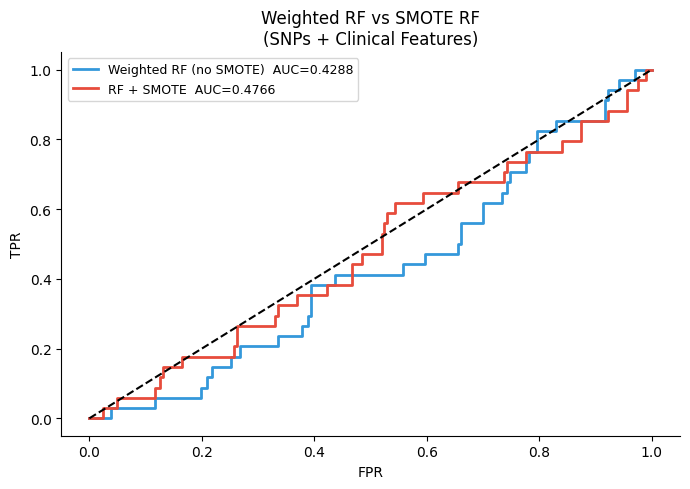


── FINAL SUMMARY ──────────────────────────
Weighted RF  — CV: 0.5045  Test: 0.4288  Gap: 0.0758
RF + SMOTE   — CV: 0.9802  Test: 0.4766  Gap: 0.5036
Lower gap = less overfitting = more reliable


In [2]:
# Final honest comparison — with and without SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
neg, pos = (y_tr==0).sum(), (y_tr==1).sum()

# Model 1 — weighted RF no SMOTE
rf_weighted = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    class_weight={0:1, 1:neg/pos},
    random_state=42, n_jobs=-1)

# Model 2 — RF with SMOTE
rf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    random_state=42, n_jobs=-1)

print('Training Model 1 — Weighted RF (no SMOTE)...')
cv1 = cross_val_score(rf_weighted, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_weighted.fit(X_tr, y_tr)
prob1 = rf_weighted.predict_proba(X_te)[:,1]
auc1  = roc_auc_score(y_te, prob1)
print(f' CV AUC: {cv1.mean():.4f} | Test AUC: {auc1:.4f} | Gap: {cv1.mean()-auc1:.4f}')

print('\nTraining Model 2 — RF with SMOTE...')
cv2 = cross_val_score(rf_smote, X_tr_sm, y_tr_sm, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_smote.fit(X_tr_sm, y_tr_sm)
prob2 = rf_smote.predict_proba(X_te)[:,1]
auc2  = roc_auc_score(y_te, prob2)
print(f' CV AUC: {cv2.mean():.4f} | Test AUC: {auc2:.4f} | Gap: {cv2.mean()-auc2:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(7,5))
for prob, auc, name, color in [
    (prob1, auc1, 'Weighted RF (no SMOTE)', '#3498db'),
    (prob2, auc2, 'RF + SMOTE',             '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  AUC={auc:.4f}')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Weighted RF vs SMOTE RF\n(SNPs + Clinical Features)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT/'weighted_vs_smote.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── FINAL SUMMARY ──────────────────────────')
print(f'Weighted RF  — CV: {cv1.mean():.4f}  Test: {auc1:.4f}  Gap: {cv1.mean()-auc1:.4f}')
print(f'RF + SMOTE   — CV: {cv2.mean():.4f}  Test: {auc2:.4f}  Gap: {cv2.mean()-auc2:.4f}')
print('Lower gap = less overfitting = more reliable')

Training Model 1 — Weighted RF (no SMOTE)...
 CV AUC: 0.5045 | Test AUC: 0.4288 | Gap: 0.0758

Training Model 2 — RF with SMOTE...
 CV AUC: 0.9802 | Test AUC: 0.4766 | Gap: 0.5036


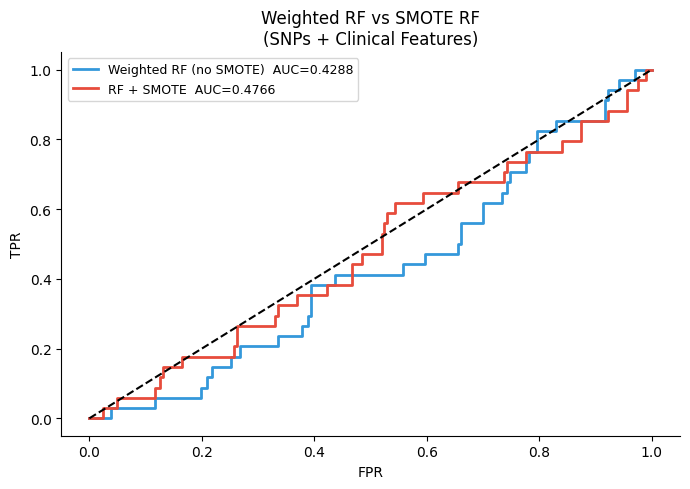


── FINAL SUMMARY ──────────────────────────
Weighted RF  — CV: 0.5045  Test: 0.4288  Gap: 0.0758
RF + SMOTE   — CV: 0.9802  Test: 0.4766  Gap: 0.5036
Lower gap = less overfitting = more reliable


In [ ]:
# Final honest comparison — with and without SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
neg, pos = (y_tr==0).sum(), (y_tr==1).sum()

# Model 1 — weighted RF no SMOTE
rf_weighted = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    class_weight={0:1, 1:neg/pos},
    random_state=42, n_jobs=-1)

# Model 2 — RF with SMOTE
rf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    random_state=42, n_jobs=-1)

print('Training Model 1 — Weighted RF (no SMOTE)...')
cv1 = cross_val_score(rf_weighted, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_weighted.fit(X_tr, y_tr)
prob1 = rf_weighted.predict_proba(X_te)[:,1]
auc1  = roc_auc_score(y_te, prob1)
print(f' CV AUC: {cv1.mean():.4f} | Test AUC: {auc1:.4f} | Gap: {cv1.mean()-auc1:.4f}')

print('\nTraining Model 2 — RF with SMOTE...')
cv2 = cross_val_score(rf_smote, X_tr_sm, y_tr_sm, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_smote.fit(X_tr_sm, y_tr_sm)
prob2 = rf_smote.predict_proba(X_te)[:,1]
auc2  = roc_auc_score(y_te, prob2)
print(f' CV AUC: {cv2.mean():.4f} | Test AUC: {auc2:.4f} | Gap: {cv2.mean()-auc2:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(7,5))
for prob, auc, name, color in [
    (prob1, auc1, 'Weighted RF (no SMOTE)', '#3498db'),
    (prob2, auc2, 'RF + SMOTE',             '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  AUC={auc:.4f}')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Weighted RF vs SMOTE RF\n(SNPs + Clinical Features)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT/'weighted_vs_smote.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── FINAL SUMMARY ──────────────────────────')
print(f'Weighted RF  — CV: {cv1.mean():.4f}  Test: {auc1:.4f}  Gap: {cv1.mean()-auc1:.4f}')
print(f'RF + SMOTE   — CV: {cv2.mean():.4f}  Test: {auc2:.4f}  Gap: {cv2.mean()-auc2:.4f}')
print('Lower gap = less overfitting = more reliable')

In [3]:
import pandas as pd
from pathlib import Path
import os

BASE  = Path(os.getcwd())
PHENO_XLSX = BASE / 'Merged file with metabolites.xlsx'

pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno = pheno.apply(lambda col: col.map(
    lambda x: x.strip() if isinstance(x, str) else x))
pheno.columns = pheno.columns.str.replace('\n',' ').str.strip()

# Metabolite columns
non_meta = ['External_ID_x','FID','IID','FID2','IID2','SAMPLEID',
            'age at consent','Gender','gall','BMI','HEMOGLOBIN A1c',
            'dys','PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8',
            'PC9','PC10','Unnamed: 16']
meta_cols = [c for c in pheno.columns if c not in non_meta]

# Find samples that HAVE metabolite data (not all NaN)
pheno['has_metabolites'] = pheno[meta_cols].notna().any(axis=1)
has_meta = pheno[pheno['has_metabolites']==True]

print(f'Total samples          : {len(pheno)}')
print(f'Samples WITH metabolites: {len(has_meta)}')
print(f'Samples WITHOUT metabolites: {len(pheno)-len(has_meta)}')
print()

# Check gall distribution in those with metabolites
has_meta_gall = has_meta['gall'].str.lower().value_counts()
print(f'Cases   (gall=Yes) with metabolites: {has_meta_gall.get("yes",0)}')
print(f'Controls (gall=No) with metabolites: {has_meta_gall.get("no",0)}')
print()
print('IID2 sample (with metabolites):')
print(has_meta['IID2'].dropna().head(10).tolist())

Total samples          : 3700
Samples WITH metabolites: 313
Samples WITHOUT metabolites: 3387

Cases   (gall=Yes) with metabolites: 21
Controls (gall=No) with metabolites: 292

IID2 sample (with metabolites):
['21-1079', '21-2254', '21-1167', '21-2611', '20-234', '21-1119', '21-180', '21-2033', '20-52', '21-81']


In [4]:
import pandas as pd
from pathlib import Path

BASE = Path(os.getcwd())

# Load the final_merged_cleaned file - this might have the mapping
try:
    fm = pd.read_excel(BASE / 'final_merged_cleaned.xlsx', dtype=str)
    print('final_merged_cleaned shape:', fm.shape)
    print('Columns:', list(fm.columns[:15]))
    print()
    print('First 3 rows:')
    print(fm.iloc[:3, :10].to_string())
except Exception as e:
    print('Error:', e)

print()
print('─'*50)

# Load final_merged_with_yang_ids
try:
    fy = pd.read_excel(BASE / 'final_merged_with_yang_ids.xlsx', dtype=str)
    print('final_merged_with_yang_ids shape:', fy.shape)
    print('Columns:', list(fy.columns[:15]))
    print()
    print('First 3 rows:')
    print(fy.iloc[:3, :10].to_string())
except Exception as e:
    print('Error:', e)

print()
print('─'*50)

# Load Merged_YangGWAS_ID11JUNE
try:
    yg = pd.read_excel(BASE / 'Merged_YangGWAS_ID11JUNE.xlsx', dtype=str)
    print('Merged_YangGWAS_ID11JUNE shape:', yg.shape)
    print('Columns:', list(yg.columns[:15]))
    print()
    print('First 3 rows:')
    print(yg.iloc[:3, :10].to_string())
except Exception as e:
    print('Error:', e)

final_merged_cleaned shape: (3700, 320)
Columns: ['External_ID_x', 'External_ID', 'sampid', 'FID', 'IID', 'FID2', 'IID2', 'SAMPLEID', 'age at\nconsent', 'Gender', 'gall', 'BMI', 'HEMOGLOBIN\nA1c', 'dys', 'PC1']

First 3 rows:
  External_ID_x External_ID       sampid          FID          IID     FID2     IID2 SAMPLEID age at\nconsent  Gender
0      EX000017    EX000017  19196002577  19196002577  19196002577  21-1079  21-1079      NaN              54    Male
1      EX000442    EX000442  19196003798  19196003798  19196003798  21-2254  21-2254      NaN              37  Female
2      EX000589    EX000589  19196002667  19196002667  19196002667  21-1167  21-1167      NaN              56  Female

──────────────────────────────────────────────────
final_merged_with_yang_ids shape: (3700, 321)
Columns: ['External_ID_x', 'External_ID', 'sampid', 'FID', 'IID', 'FID2', 'IID2', 'SAMPLEID', 'age at\nconsent', 'Gender', 'gall', 'BMI', 'HEMOGLOBIN\nA1c', 'dys', 'PC1']

First 3 rows:
  External_ID_x Ex

In [5]:
import pandas as pd
from pathlib import Path

BASE = Path(os.getcwd())

# Check SAMPLEID in final_merged_cleaned
fm = pd.read_excel(BASE / 'final_merged_cleaned.xlsx', dtype=str)
fm.columns = fm.columns.str.replace('\n',' ').str.strip()

# How many have SAMPLEID
has_sid = fm[fm['SAMPLEID'].notna() & (fm['SAMPLEID'].str.strip() != '')]
print(f'Rows with SAMPLEID     : {len(has_sid)}')
print(f'Rows WITHOUT SAMPLEID  : {len(fm) - len(has_sid)}')
print()
print('SAMPLEID sample values:')
print(has_sid['SAMPLEID'].head(10).tolist())
print()
print('gall distribution for rows WITH SAMPLEID:')
print(has_sid['gall'].str.lower().value_counts())
print()
print('IID2 for rows with SAMPLEID:')
print(has_sid['IID2'].head(10).tolist())
print()

# Check if SAMPLEID matches Sample 1, Sample 2... format
print('SAMPLEID unique values (first 20):')
print(has_sid['SAMPLEID'].unique()[:20])

Rows with SAMPLEID     : 310
Rows WITHOUT SAMPLEID  : 3390

SAMPLEID sample values:
['1605404009', '1502704043', '1407006317', '1412007562', '17244004519', '1615403225', '16313004734', '1527905746', '1523705003', '1621003131']

gall distribution for rows WITH SAMPLEID:
gall
no     210
yes    100
Name: count, dtype: int64

IID2 for rows with SAMPLEID:
['21-85', '20-795', '20-246', '20-991', '21-1291', '21-1153', '21-1831', '21-579', '21-1389', '21-1112']

SAMPLEID unique values (first 20):
<StringArray>
[ '1605404009',  '1502704043',  '1407006317',  '1412007562', '17244004519',
  '1615403225', '16313004734',  '1527905746',  '1523705003',  '1621003131',
  '1321304182',  '1511103705',  '1428004373',  '1435005489', '17174004009',
 '17192004696', '17109003670',  '1620803219',  '1511103758', '18009009923']
Length: 20, dtype: str


In [10]:
import pandas as pd
from pathlib import Path

BASE = Path(os.getcwd())

# Check clean_metabolite_dataset.xlsx
try:
    clean = pd.read_excel(BASE / 'clean_metabolite_dataset.xlsx', dtype=str)
    print('clean_metabolite_dataset shape:', clean.shape)
    print('Columns:', list(clean.columns[:10]))
    print('First 3 rows:')
    print(clean.iloc[:3, :8].to_string())
except Exception as e:
    print('clean_metabolite_dataset error:', e)

print()

# Check top_metabolites.xlsx
try:
    top = pd.read_excel(BASE / 'top_metabolites.xlsx', dtype=str)
    print('top_metabolites shape:', top.shape)
    print('Columns:', list(top.columns[:10]))
    print('First 3 rows:')
    print(top.iloc[:3, :8].to_string())
except Exception as e:
    print('top_metabolites error:', e)

clean_metabolite_dataset shape: (3700, 320)
Columns: ['External_ID_x', 'External_ID', 'sampid', 'FID', 'IID', 'FID2', 'IID2', 'SAMPLEID', 'age at\nconsent', 'Gender']
First 3 rows:
  External_ID_x External_ID       sampid          FID          IID     FID2     IID2 SAMPLEID
0      EX000017    EX000017  19196002577  19196002577  19196002577  21-1079  21-1079      NaN
1      EX000442    EX000442  19196003798  19196003798  19196003798  21-2254  21-2254      NaN
2      EX000589    EX000589  19196002667  19196002667  19196002667  21-1167  21-1167      NaN

top_metabolites shape: (309, 2)
Columns: ['Metabolite', 'Importance']
First 3 rows:
  Metabolite          Importance
0        PC1  0.1422579689252452
1        PC4   0.142003600261623
2        PC3  0.1392214779394564


 Packages ready
BASE: c:\Users\bsevak\Documents\project_data

 Khadijah samples: 310
   Cases   : 100
   Controls: 210

 Features available:
   PCs         : 4  ['PC1', 'PC2', 'PC3', 'PC4']
   Clinical    : 4 ['age at consent', 'Gender', 'BMI', 'HEMOGLOBIN A1c']
   Metabolites : 302

 SNPs: 479
  CDHR3_region.raw: 36 SNPs
  CLDN7_region.raw: 41 SNPs
  CPZ_region.raw: 51 SNPs
  ERICH1_region.raw: 42 SNPs
  EXOC4_region.raw: 39 SNPs
  GALNTL6_region.raw: 44 SNPs
  GPC6_region.raw: 33 SNPs
  GPRIN3_region.raw: 13 SNPs
  HLA-G_region.raw: 19 SNPs
  HMGB1P5_region.raw: 16 SNPs
  LINC01122_region.raw: 10 SNPs
  LRP8_region.raw: 13 SNPs
  LUZP2_region.raw: 16 SNPs
  MATN2_region.raw: 11 SNPs
  OSBPL10_region.raw: 18 SNPs
  PALM2AKAP2_region.raw: 8 SNPs
  PTPRN2_region.raw: 14 SNPs
  RNFT2_region.raw: 19 SNPs
  RPL31P35_region.raw: 10 SNPs
  TJP1_region.raw: 9 SNPs
  UGGT1_region.raw: 17 SNPs

 Genotype: (305, 480)

 Final merged: (305, 793)
   Cases   : 98
   Controls: 207
   SNPs    : 479
  

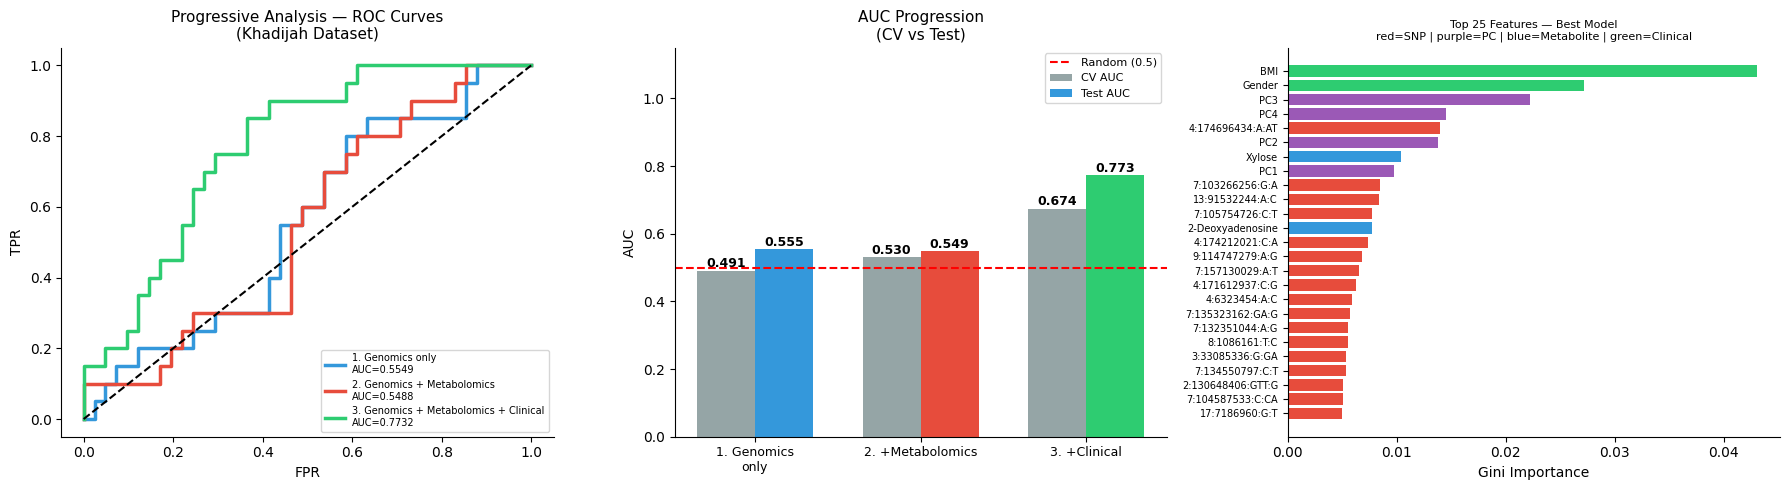

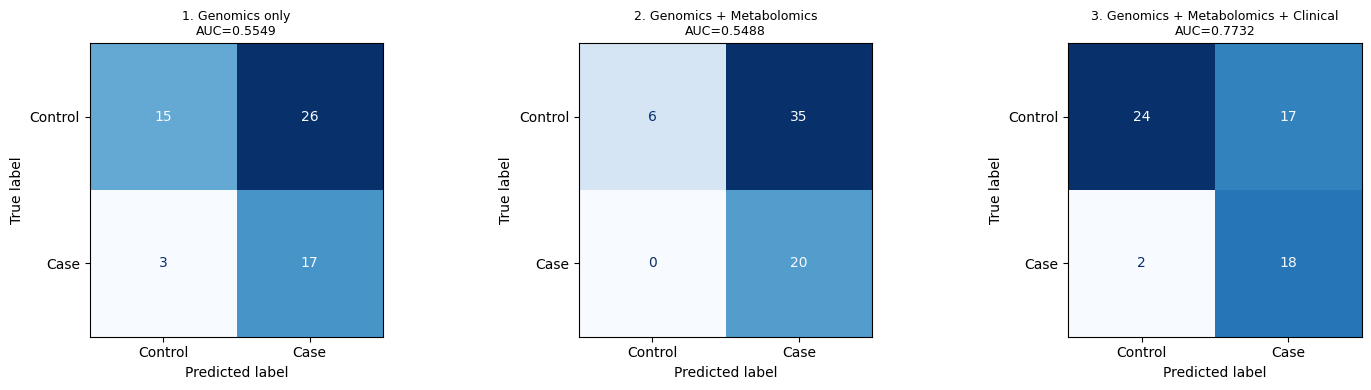


   PROGRESSIVE ANALYSIS COMPLETE — Khadijah Dataset
  Samples  : 305 (98 cases + 207 controls)
  Algorithm: BalancedRandomForest (bootstrap-based)


,Feature Set,N Features,CV AUC,CV AUC std,Test AUC,CV-Test Gap,N Samples,N Cases,N Controls
0,1. Genomics only,479,0.4908,0.0819,0.5549,-0.0640,305,98,207
1,2. Genomics + Metabolomics,785,0.5305,0.1045,0.5488,-0.0182,305,98,207
2,3. Genomics + Metabolomics + Clinical,789,0.6741,0.0598,0.7732,-0.0991,305,98,207


In [11]:
import os, warnings, sys, subprocess
from pathlib import Path

for pkg in ['pandas','numpy','scipy','scikit-learn','matplotlib','seaborn','openpyxl','imbalanced-learn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'])
print(' Packages ready')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from imblearn.ensemble import BalancedRandomForestClassifier
warnings.filterwarnings('ignore')
%matplotlib inline

BASE       = Path(os.getcwd())
OUT        = BASE / 'gwas_output'
OUT.mkdir(exist_ok=True)
SNP_CSV    = BASE / 'summary_results sorted by p (1).csv'
PHENO_XLSX = BASE / 'final_merged_cleaned.xlsx'

print(f'BASE: {BASE}')

# ── STEP 1: Load phenotype — Khadijah 310 samples (WITH SAMPLEID) ─────────────
pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno = pheno.apply(lambda col: col.map(
    lambda x: x.strip() if isinstance(x, str) else x))
pheno.columns = pheno.columns.str.replace('\n',' ').str.strip()

# Filter to samples WITH SAMPLEID = have metabolite data
pheno_k = pheno[pheno['SAMPLEID'].notna() &
                (pheno['SAMPLEID'].str.strip() != '')].copy()
pheno_k['gall']  = pheno_k['gall'].str.lower()
pheno_k          = pheno_k[pheno_k['gall'].isin({'yes','no'})].copy()
pheno_k['label'] = (pheno_k['gall']=='yes').astype(int)
pheno_k['IID2']  = pheno_k['IID2'].astype(str)

print(f'\n Khadijah samples: {len(pheno_k)}')
print(f'   Cases   : {pheno_k["label"].sum()}')
print(f'   Controls: {(pheno_k["label"]==0).sum()}')

# ── STEP 2: Get feature columns ───────────────────────────────────────────────
non_feat = ['External_ID_x','External_ID','sampid','FID','IID','FID2',
            'IID2','SAMPLEID','gall','dys','Unnamed: 16']
pc_cols  = ['PC1','PC2','PC3','PC4']
clin_cols= ['age at consent','Gender','BMI','HEMOGLOBIN A1c']
meta_cols= [c for c in pheno_k.columns
            if c not in non_feat + pc_cols + clin_cols
            and not c.startswith('PC')
            and not c.startswith('Unnamed')
            and c != 'label']

# Encode Gender
if 'Gender' in pheno_k.columns:
    pheno_k['Gender'] = LabelEncoder().fit_transform(
        pheno_k['Gender'].fillna('Unknown'))

# Convert to numeric
for col in clin_cols + pc_cols + meta_cols:
    if col in pheno_k.columns:
        pheno_k[col] = pd.to_numeric(pheno_k[col], errors='coerce')

available_clin = [c for c in clin_cols if c in pheno_k.columns]
available_meta = [c for c in meta_cols if c in pheno_k.columns]
available_pcs  = [c for c in pc_cols  if c in pheno_k.columns]

print(f'\n Features available:')
print(f'   PCs         : {len(available_pcs)}  {available_pcs}')
print(f'   Clinical    : {len(available_clin)} {available_clin}')
print(f'   Metabolites : {len(available_meta)}')

# ── STEP 3: Load SNPs ─────────────────────────────────────────────────────────
snp_raw = pd.read_csv(SNP_CSV)
snp_raw = snp_raw[snp_raw['MinP'] <= 1e-5]
snp_df  = (snp_raw[['Gene','TopSNP','MinP']]
           .sort_values('MinP')
           .drop_duplicates(subset='TopSNP')
           .reset_index(drop=True))
print(f'\n SNPs: {len(snp_df)}')

# ── STEP 4: Load genotype ─────────────────────────────────────────────────────
def load_raw(raw_path, snp_list):
    header  = pd.read_csv(raw_path, sep=r'\s+', nrows=0)
    snp_set = set(snp_list)
    col_map = {c: c.rsplit('_',1)[0] for c in header.columns
               if c.rsplit('_',1)[0] in snp_set}
    if not col_map:
        return pd.DataFrame()
    df = pd.read_csv(raw_path, sep=r'\s+',
                     usecols=['IID']+list(col_map), low_memory=False)
    df.rename(columns=col_map, inplace=True)
    df['IID'] = df['IID'].astype(str)
    print(f'  {raw_path.name}: {len(col_map)} SNPs')
    return df

raw_files    = sorted(BASE.glob('*_region.raw'))
gene_map     = {f.stem.replace('_region','').strip('_').upper(): f
                for f in raw_files}
gene_snps    = snp_df.groupby('Gene')['TopSNP'].apply(list).to_dict()
khadijah_iids= set(pheno_k['IID2'].tolist())

frames = []
for gene, snps in gene_snps.items():
    g    = gene.upper().strip()
    path = gene_map.get(g)
    if path is None:
        matches = [k for k in gene_map if k.startswith(g) or g.startswith(k)]
        path = gene_map[matches[0]] if matches else None
    if path is None:
        print(f'WARNING: no .raw for {gene}')
        continue
    chunk = load_raw(path, snps)
    if not chunk.empty:
        frames.append(chunk)

geno = frames[0]
for f in frames[1:]:
    geno = pd.merge(geno, f, on='IID', how='outer')
geno          = geno.loc[:, ~geno.columns.duplicated()]
geno_filtered = geno[geno['IID'].isin(khadijah_iids)].copy()
print(f'\n Genotype: {geno_filtered.shape}')

# ── STEP 5: Merge ─────────────────────────────────────────────────────────────
keep = (['IID2','gall','label'] + available_pcs +
        available_clin + available_meta)
keep = [c for c in keep if c in pheno_k.columns]

merged = pd.merge(geno_filtered,
                  pheno_k[keep],
                  left_on='IID', right_on='IID2', how='inner')

snp_cols = [c for c in merged.columns if c in set(geno.columns)-{'IID'}]
merged['label'] = merged['label'].astype(int)

print(f'\n Final merged: {merged.shape}')
print(f'   Cases   : {merged["label"].sum()}')
print(f'   Controls: {(merged["label"]==0).sum()}')
print(f'   SNPs    : {len(snp_cols)}')
print(f'   Metabolites: {len(available_meta)}')
print(f'   PCs     : {len(available_pcs)}')
print(f'   Clinical: {len(available_clin)}')
merged.to_csv(OUT/'khadijah_merged_dataset.csv', index=False)

# ── STEP 6: Define progressive feature sets ───────────────────────────────────
feature_sets = {
    '1. Genomics only\n(SNPs)':
        snp_cols,

    '2. Genomics + Metabolomics\n(SNPs + PCs + Metabolites)':
        snp_cols + available_pcs + available_meta,

    '3. Genomics + Metabolomics + Clinical\n(SNPs + PCs + Metabolites + Clinical)':
        snp_cols + available_pcs + available_meta + available_clin,
}

print('\n Feature sets:')
for name, cols in feature_sets.items():
    print(f'   {name.split(chr(10))[0]}: {len(cols)} features')

# ── STEP 7: Train BalancedRandomForest for each feature set ───────────────────
cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []
trained      = {}

for name, feat_cols in feature_sets.items():
    short = name.split('\n')[0]
    print(f'\nTraining: {short} ...')

    X = SimpleImputer(strategy='median').fit_transform(
        merged[feat_cols].apply(pd.to_numeric, errors='coerce'))
    y = merged['label'].astype(int).values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)

    # BalancedRandomForest = bootstrap-based imbalance handling
    # as suggested by Prof. Valentin
    model = BalancedRandomForestClassifier(
        n_estimators      = 200,
        max_depth         = 6,
        random_state      = 42,
        n_jobs            = -1,
        sampling_strategy = 'auto',
        replacement       = True
    )

    cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:,1]

    prec,rec,thr = precision_recall_curve(y_te, y_prob)
    f1s         = 2*prec*rec/(prec+rec+1e-8)
    best_thresh = thr[np.argmax(f1s)]
    y_pred      = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_te, y_prob)
    acc = accuracy_score(y_te, y_pred)

    print(f'   CV AUC : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')
    print(f'   Test AUC: {auc:.4f} | Accuracy: {acc:.4f}')
    print(classification_report(y_te, y_pred,
                                 target_names=['Control','Case']))

    trained[name] = (model, auc, y_prob, y_pred, feat_cols, y_te)
    results_list.append({
        'Feature Set' : short,
        'N Features'  : len(feat_cols),
        'CV AUC'      : round(cv_auc.mean(), 4),
        'CV AUC std'  : round(cv_auc.std(),  4),
        'Test AUC'    : round(auc, 4),
        'CV-Test Gap' : round(cv_auc.mean()-auc, 4),
        'N Samples'   : len(merged),
        'N Cases'     : int(y.sum()),
        'N Controls'  : int((y==0).sum()),
    })

# ── STEP 8: Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db','#e74c3c','#2ecc71']

# ROC curves
for (name,(model,auc,y_prob,_,_,y_te)),color in zip(trained.items(),colors):
    fpr,tpr,_ = roc_curve(y_te, y_prob)
    short = name.split('\n')[0]
    axes[0].plot(fpr, tpr, lw=2.5, color=color,
                 label=f'{short}\nAUC={auc:.4f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Progressive Analysis — ROC Curves\n(Khadijah Dataset)', fontsize=11)
axes[0].legend(fontsize=7, loc='lower right')
axes[0].spines[['top','right']].set_visible(False)

# AUC progression bar chart
names_s  = ['1. Genomics\nonly',
            '2. +Metabolomics',
            '3. +Clinical']
aucs     = [r['Test AUC'] for r in results_list]
cv_aucs  = [r['CV AUC']   for r in results_list]
x = np.arange(3); w = 0.35
axes[1].bar(x-w/2, cv_aucs, w, label='CV AUC',   color='#95a5a6')
axes[1].bar(x+w/2, aucs,    w, label='Test AUC', color=colors)
for i,(cv,te) in enumerate(zip(cv_aucs,aucs)):
    axes[1].text(i-w/2, cv+0.01, f'{cv:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i+w/2, te+0.01, f'{te:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random (0.5)')
axes[1].set_xticks(x); axes[1].set_xticklabels(names_s, fontsize=9)
axes[1].set_ylabel('AUC'); axes[1].set_ylim(0, 1.15)
axes[1].set_title('AUC Progression\n(CV vs Test)', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

# Feature importance — best model
best_name = max(trained, key=lambda x: trained[x][1])
best_model,best_auc,_,_,best_feats,_ = trained[best_name]
imp   = best_model.feature_importances_
top_n = min(25, len(best_feats))
idx   = np.argsort(imp)[::-1][:top_n]
cb    = []
for i in idx:
    if best_feats[i] in snp_cols:          cb.append('#e74c3c')
    elif best_feats[i] in available_pcs:   cb.append('#9b59b6')
    elif best_feats[i] in available_meta:  cb.append('#3498db')
    else:                                   cb.append('#2ecc71')
axes[2].barh(range(top_n), imp[idx][::-1], color=cb[::-1])
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels([best_feats[i] for i in idx][::-1], fontsize=7)
axes[2].set_xlabel('Gini Importance')
axes[2].set_title(f'Top {top_n} Features — Best Model\nred=SNP | purple=PC | blue=Metabolite | green=Clinical',
                  fontsize=8)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT/'khadijah_progressive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1,3,figsize=(15,4))
for i,(name,(model,auc,y_prob,y_pred,_,y_te)) in enumerate(trained.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=['Control','Case']
    ).plot(ax=axes[i], colorbar=False, cmap='Blues')
    short = name.split('\n')[0]
    axes[i].set_title(f'{short}\nAUC={auc:.4f}', fontsize=9)
plt.tight_layout()
plt.savefig(OUT/'khadijah_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── STEP 9: Save results ──────────────────────────────────────────────────────
results_df = pd.DataFrame(results_list)
results_df.to_csv(OUT/'khadijah_progressive_results.csv', index=False)

print('\n'+'='*65)
print('   PROGRESSIVE ANALYSIS COMPLETE — Khadijah Dataset')
print(f'  Samples  : {len(merged)} ({merged["label"].sum()} cases + {(merged["label"]==0).sum()} controls)')
print('  Algorithm: BalancedRandomForest (bootstrap-based)')
print('='*65)
display(results_df)

In [12]:
import pandas as pd
from pathlib import Path

BASE       = Path(os.getcwd())
PHENO_XLSX = BASE / 'final_merged_cleaned.xlsx'

pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno.columns = pheno.columns.str.replace('\n',' ').str.strip()

# How many cases have SAMPLEID
cases_all        = pheno[pheno['gall'].str.lower()=='yes']
cases_with_sid   = cases_all[cases_all['SAMPLEID'].notna() &
                              (cases_all['SAMPLEID'].str.strip()!='')]
cases_without_sid= cases_all[cases_all['SAMPLEID'].isna() |
                              (cases_all['SAMPLEID'].str.strip()=='')]

print(f'Total cases                    : {len(cases_all)}')
print(f'Cases WITH SAMPLEID            : {len(cases_with_sid)}')
print(f'Cases WITHOUT SAMPLEID         : {len(cases_without_sid)}')
print()
print(f'IID2 for cases WITH SAMPLEID:')
print(cases_with_sid['IID2'].tolist())
print()
print(f'IID2 for cases WITHOUT SAMPLEID (first 10):')
print(cases_without_sid['IID2'].tolist()[:10])
print()

# Check if batch1 metabolomics file has more cases
# The 218 samples in Khadijah paper used SAMPLEID not IID2
print('SAMPLEID values for cases:')
print(cases_with_sid['SAMPLEID'].tolist())

Total cases                    : 172
Cases WITH SAMPLEID            : 100
Cases WITHOUT SAMPLEID         : 72

IID2 for cases WITH SAMPLEID:
['20-795', '20-246', '21-1831', '21-579', '21-1389', '20-498', '21-137', '20-811', '21-1550', '21-433', '21-412', '21-1124', '21-818', '20-717', '21-1941', '21-2431', '21-775', '21-314', '21-689', '20-436', '21-706', '21-244', '20-817', '20-119', '21-1778', '21-357', '2025-07-21 00:00:00', '21-1305', '21-2092', '21-1347', '21-592', '21-2555', '21-2176', '21-1545', '21-1520', '21-563', '20-804', '21-1214', '21-1686', '21-93', '21-2453', '20-873', '21-2663', '20-767', '21-1313', '20-826', '21-2520', '21-1846', '21-1967', '21-698', '21-1603', '21-1332', '21-1755', '21-1684', '21-1951', '21-1917', '20-55', '21-1708', '21-1339', '20-209', '21-1769', '21-2193', '2025-08-21 00:00:00', '21-889', '20-830', '21-2214', '21-270', '21-587', '20-155', '21-1383', '21-363', '21-827', '21-44', '21-1577', '21-1180', '20-97', '21-1876', '21-963', '21-2036', '21-2019

In [13]:
import pandas as pd
from pathlib import Path

BASE       = Path(os.getcwd())
PHENO_XLSX = BASE / 'final_merged_cleaned.xlsx'

# Reload with IID2 protected from date conversion
pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno.columns = pheno.columns.str.replace('\n',' ').str.strip()

# Fix corrupted IID2 date values
# Excel converted '20-21' -> '2025-07-21 00:00:00' etc
# Pattern: '2025-MM-21' should be '20-MM' where MM is month number... 
# Let's see all corrupted values
corrupted = pheno[pheno['IID2'].str.contains('2025', na=False)]
print(f'Corrupted IID2 values: {len(corrupted)}')
print(corrupted[['IID2','SAMPLEID','gall']].to_string())
print()

# Also check IID column for same issue
corrupted_iid = pheno[pheno['IID'].str.contains('2025', na=False)]
print(f'Corrupted IID values: {len(corrupted_iid)}')
print(corrupted_iid[['IID','IID2','SAMPLEID','gall']].head(10).to_string())

Corrupted IID2 values: 24
                     IID2    SAMPLEID gall
28    2025-02-20 00:00:00         NaN   No
189   2025-08-20 00:00:00         NaN   No
806   2025-10-21 00:00:00         NaN   No
838   2025-07-21 00:00:00  1624304275  Yes
1300              21-2025         NaN   No
1321  2025-12-21 00:00:00         NaN   No
1382  2025-06-20 00:00:00  1514803199   No
1518  2025-10-20 00:00:00         NaN   No
1657  2025-04-20 00:00:00         NaN   No
1801  2025-11-20 00:00:00  1407206178   No
1884  2025-02-21 00:00:00         NaN   No
1932  2025-06-21 00:00:00         NaN   No
1965  2025-01-20 00:00:00         NaN   No
2117  2025-05-20 00:00:00         NaN   No
2402  2025-04-21 00:00:00         NaN   No
2541  2025-08-21 00:00:00  1326103783  Yes
2545  2025-09-21 00:00:00         NaN   No
2665  2025-03-20 00:00:00  1322508067   No
3117  2025-12-20 00:00:00         NaN   No
3175  2025-03-21 00:00:00         NaN   No
3244  2025-11-21 00:00:00         NaN   No
3431  2025-05-21 00:00:00   

In [14]:
import pandas as pd
from pathlib import Path

BASE       = Path(os.getcwd())
PHENO_XLSX = BASE / 'final_merged_cleaned.xlsx'

pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno.columns = pheno.columns.str.replace('\n',' ').str.strip()

def fix_iid2(val):
    if pd.isna(val):
        return val
    val = str(val).strip()
    # Pattern: '2025-MM-DD 00:00:00' or '2025-MM-DD'
    if val.startswith('2025-') and ('00:00:00' in val or len(val)==10):
        try:
            # Extract month and day
            parts = val.replace(' 00:00:00','').split('-')
            month = parts[1]   # MM
            day   = parts[2]   # DD (which is actually the year prefix 20 or 21)
            # day=20 means prefix '20-', day=21 means prefix '21-'
            return f'{day}-{month}'
        except:
            return val
    return val

# Apply fix
pheno['IID2_fixed'] = pheno['IID2'].apply(fix_iid2)

# Show fixed values
fixed = pheno[pheno['IID2'].str.contains('2025', na=False)]
print('Fixed IID2 values:')
print(fixed[['IID2','IID2_fixed','SAMPLEID','gall']].to_string())
print()

# Verify cases
cases_fixed = pheno[pheno['gall'].str.lower()=='yes'].copy()
cases_fixed['IID2_fixed'] = cases_fixed['IID2'].apply(fix_iid2)
print(f'Total cases          : {len(cases_fixed)}')
print(f'Cases with SAMPLEID  : {cases_fixed["SAMPLEID"].notna().sum()}')
print(f'Cases IID2 sample    : {cases_fixed["IID2_fixed"].tolist()[:5]}')

Fixed IID2 values:
                     IID2 IID2_fixed    SAMPLEID gall
28    2025-02-20 00:00:00      20-02         NaN   No
189   2025-08-20 00:00:00      20-08         NaN   No
806   2025-10-21 00:00:00      21-10         NaN   No
838   2025-07-21 00:00:00      21-07  1624304275  Yes
1300              21-2025    21-2025         NaN   No
1321  2025-12-21 00:00:00      21-12         NaN   No
1382  2025-06-20 00:00:00      20-06  1514803199   No
1518  2025-10-20 00:00:00      20-10         NaN   No
1657  2025-04-20 00:00:00      20-04         NaN   No
1801  2025-11-20 00:00:00      20-11  1407206178   No
1884  2025-02-21 00:00:00      21-02         NaN   No
1932  2025-06-21 00:00:00      21-06         NaN   No
1965  2025-01-20 00:00:00      20-01         NaN   No
2117  2025-05-20 00:00:00      20-05         NaN   No
2402  2025-04-21 00:00:00      21-04         NaN   No
2541  2025-08-21 00:00:00      21-08  1326103783  Yes
2545  2025-09-21 00:00:00      21-09         NaN   No
2665  202

 Packages ready
 IID2 date fix applied

 Samples with SAMPLEID: 310
   Cases   : 100
   Controls: 210

Features available:
   PCs        : 4
   Clinical   : 4
   Metabolites: 302

 SNPs: 479
  CDHR3_region.raw: 36 SNPs
  CLDN7_region.raw: 41 SNPs
  CPZ_region.raw: 51 SNPs
  ERICH1_region.raw: 42 SNPs
  EXOC4_region.raw: 39 SNPs
  GALNTL6_region.raw: 44 SNPs
  GPC6_region.raw: 33 SNPs
  GPRIN3_region.raw: 13 SNPs
  HLA-G_region.raw: 19 SNPs
  HMGB1P5_region.raw: 16 SNPs
  LINC01122_region.raw: 10 SNPs
  LRP8_region.raw: 13 SNPs
  LUZP2_region.raw: 16 SNPs
  MATN2_region.raw: 11 SNPs
  OSBPL10_region.raw: 18 SNPs
  PALM2AKAP2_region.raw: 8 SNPs
  PTPRN2_region.raw: 14 SNPs
  RNFT2_region.raw: 19 SNPs
  RPL31P35_region.raw: 10 SNPs
  TJP1_region.raw: 9 SNPs
  UGGT1_region.raw: 17 SNPs

 Genotype filtered: (306, 480)

Final merged: (306, 793)
   Cases   : 98
   Controls: 208
   SNPs    : 479

Feature sets:
   1. Genomics only: 479 features
   2. Genomics + Metabolomics: 785 features
   3. 

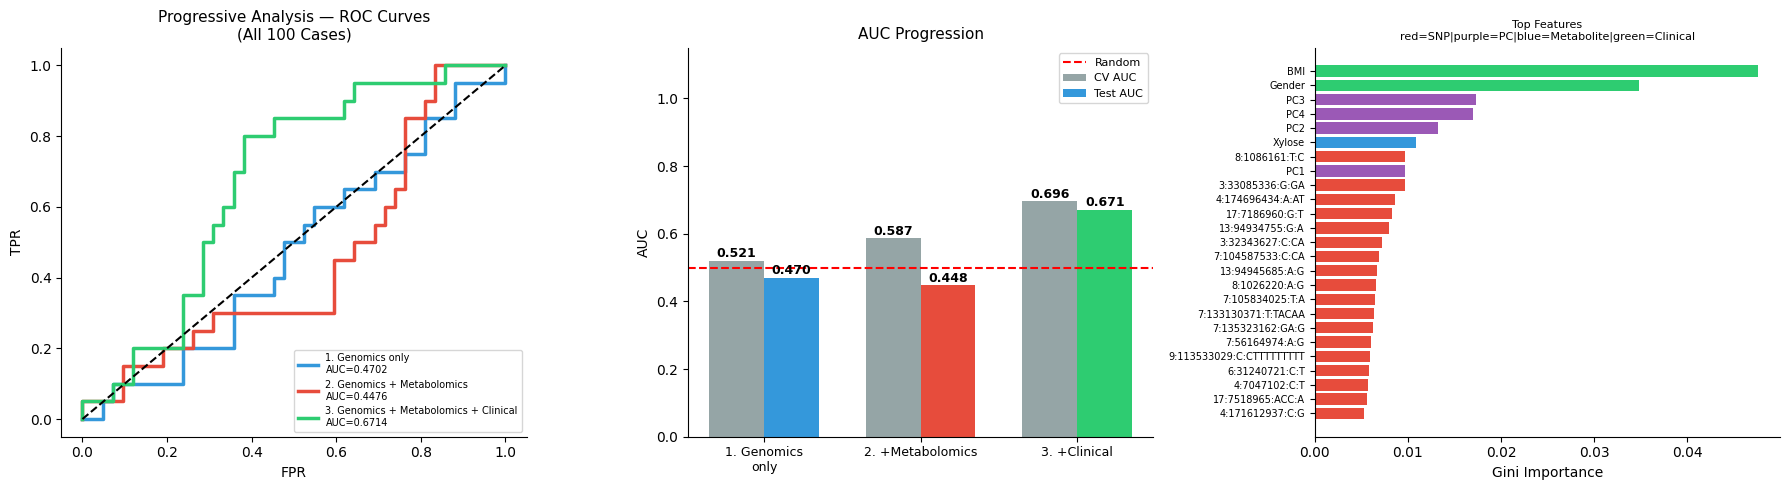

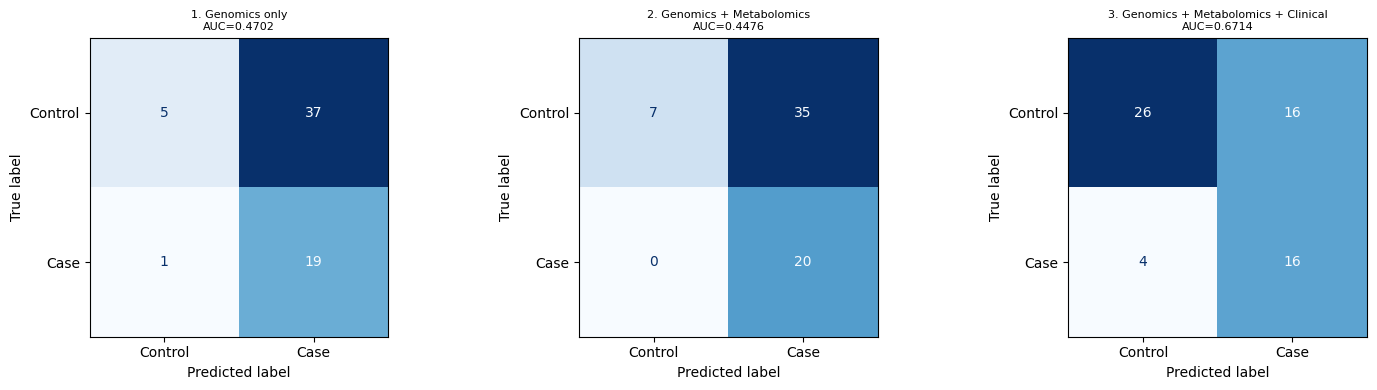


   COMPLETE — All 100 cases (Excel date fix applied)


,Feature Set,N Features,CV AUC,CV AUC std,Test AUC,CV-Test Gap,N Samples,N Cases,N Controls
0,1. Genomics only,479,0.5207,0.0407,0.4702,0.0504,306,98,208
1,2. Genomics + Metabolomics,785,0.5865,0.1002,0.4476,0.1389,306,98,208
2,3. Genomics + Metabolomics + Clinical,789,0.6960,0.0494,0.6714,0.0246,306,98,208


In [1]:
import os, warnings, sys, subprocess
from pathlib import Path

for pkg in ['pandas','numpy','scipy','scikit-learn','matplotlib','seaborn','openpyxl','imbalanced-learn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'])
print(' Packages ready')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from imblearn.ensemble import BalancedRandomForestClassifier
warnings.filterwarnings('ignore')
%matplotlib inline

BASE       = Path(os.getcwd())
OUT        = BASE / 'gwas_output'
OUT.mkdir(exist_ok=True)
SNP_CSV    = BASE / 'summary_results sorted by p (1).csv'
PHENO_XLSX = BASE / 'final_merged_cleaned.xlsx'

# ── STEP 1: Load phenotype with IID2 date fix ─────────────────────────────────
def fix_iid2(val):
    if pd.isna(val):
        return val
    val = str(val).strip()
    if val.startswith('2025-') and ('00:00:00' in val or len(val)==10):
        try:
            parts = val.replace(' 00:00:00','').split('-')
            month = parts[1]
            day   = parts[2]
            return f'{day}-{month}'
        except:
            return val
    return val

pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno = pheno.apply(lambda col: col.map(
    lambda x: x.strip() if isinstance(x, str) else x))
pheno.columns = pheno.columns.str.replace('\n',' ').str.strip()
pheno['IID2'] = pheno['IID2'].apply(fix_iid2)
print(' IID2 date fix applied')

# Filter to samples WITH SAMPLEID
pheno_k = pheno[pheno['SAMPLEID'].notna() &
                (pheno['SAMPLEID'].str.strip() != '')].copy()
pheno_k['gall']  = pheno_k['gall'].str.lower()
pheno_k          = pheno_k[pheno_k['gall'].isin({'yes','no'})].copy()
pheno_k['label'] = (pheno_k['gall']=='yes').astype(int)
pheno_k['IID2']  = pheno_k['IID2'].astype(str)

print(f'\n Samples with SAMPLEID: {len(pheno_k)}')
print(f'   Cases   : {pheno_k["label"].sum()}')
print(f'   Controls: {(pheno_k["label"]==0).sum()}')

# ── STEP 2: Feature columns ───────────────────────────────────────────────────
non_feat  = ['External_ID_x','External_ID','sampid','FID','IID','FID2',
             'IID2','SAMPLEID','gall','dys','Unnamed: 16']
pc_cols   = ['PC1','PC2','PC3','PC4']
clin_cols = ['age at consent','Gender','BMI','HEMOGLOBIN A1c']
meta_cols = [c for c in pheno_k.columns
             if c not in non_feat + pc_cols + clin_cols
             and not c.startswith('PC')
             and not c.startswith('Unnamed')
             and c != 'label']

if 'Gender' in pheno_k.columns:
    pheno_k['Gender'] = LabelEncoder().fit_transform(
        pheno_k['Gender'].fillna('Unknown'))
for col in clin_cols + pc_cols + meta_cols:
    if col in pheno_k.columns:
        pheno_k[col] = pd.to_numeric(pheno_k[col], errors='coerce')

available_clin = [c for c in clin_cols if c in pheno_k.columns]
available_meta = [c for c in meta_cols if c in pheno_k.columns]
available_pcs  = [c for c in pc_cols   if c in pheno_k.columns]

print(f'\nFeatures available:')
print(f'   PCs        : {len(available_pcs)}')
print(f'   Clinical   : {len(available_clin)}')
print(f'   Metabolites: {len(available_meta)}')

# ── STEP 3: Load SNPs ─────────────────────────────────────────────────────────
snp_raw = pd.read_csv(SNP_CSV)
snp_raw = snp_raw[snp_raw['MinP'] <= 1e-5]
snp_df  = (snp_raw[['Gene','TopSNP','MinP']]
           .sort_values('MinP')
           .drop_duplicates(subset='TopSNP')
           .reset_index(drop=True))
print(f'\n SNPs: {len(snp_df)}')

# ── STEP 4: Load genotype ─────────────────────────────────────────────────────
def load_raw(raw_path, snp_list):
    header  = pd.read_csv(raw_path, sep=r'\s+', nrows=0)
    snp_set = set(snp_list)
    col_map = {c: c.rsplit('_',1)[0] for c in header.columns
               if c.rsplit('_',1)[0] in snp_set}
    if not col_map:
        return pd.DataFrame()
    df = pd.read_csv(raw_path, sep=r'\s+',
                     usecols=['IID']+list(col_map), low_memory=False)
    df.rename(columns=col_map, inplace=True)
    df['IID'] = df['IID'].astype(str)
    print(f'  {raw_path.name}: {len(col_map)} SNPs')
    return df

raw_files     = sorted(BASE.glob('*_region.raw'))
gene_map      = {f.stem.replace('_region','').strip('_').upper(): f
                 for f in raw_files}
gene_snps     = snp_df.groupby('Gene')['TopSNP'].apply(list).to_dict()
khadijah_iids = set(pheno_k['IID2'].tolist())

frames = []
for gene, snps in gene_snps.items():
    g    = gene.upper().strip()
    path = gene_map.get(g)
    if path is None:
        matches = [k for k in gene_map if k.startswith(g) or g.startswith(k)]
        path = gene_map[matches[0]] if matches else None
    if path is None:
        print(f'WARNING: no .raw for {gene}')
        continue
    chunk = load_raw(path, snps)
    if not chunk.empty:
        frames.append(chunk)

geno = frames[0]
for f in frames[1:]:
    geno = pd.merge(geno, f, on='IID', how='outer')
geno          = geno.loc[:, ~geno.columns.duplicated()]
geno_filtered = geno[geno['IID'].isin(khadijah_iids)].copy()
print(f'\n Genotype filtered: {geno_filtered.shape}')

# ── STEP 5: Merge ─────────────────────────────────────────────────────────────
keep = (['IID2','gall','label'] + available_pcs +
        available_clin + available_meta)
keep = [c for c in keep if c in pheno_k.columns]

merged = pd.merge(geno_filtered,
                  pheno_k[keep],
                  left_on='IID', right_on='IID2', how='inner')

snp_cols        = [c for c in merged.columns if c in set(geno.columns)-{'IID'}]
merged['label'] = merged['label'].astype(int)

print(f'\nFinal merged: {merged.shape}')
print(f'   Cases   : {merged["label"].sum()}')
print(f'   Controls: {(merged["label"]==0).sum()}')
print(f'   SNPs    : {len(snp_cols)}')
merged.to_csv(OUT/'khadijah_full_merged.csv', index=False)

# ── STEP 6: Progressive feature sets ─────────────────────────────────────────
feature_sets = {
    '1. Genomics only'                      : snp_cols,
    '2. Genomics + Metabolomics'            : snp_cols + available_pcs + available_meta,
    '3. Genomics + Metabolomics + Clinical' : snp_cols + available_pcs + available_meta + available_clin,
}
print('\nFeature sets:')
for name, cols in feature_sets.items():
    print(f'   {name}: {len(cols)} features')

# ── STEP 7: Train ─────────────────────────────────────────────────────────────
cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []
trained      = {}

for name, feat_cols in feature_sets.items():
    print(f'\nTraining: {name} ...')
    X = SimpleImputer(strategy='median').fit_transform(
        merged[feat_cols].apply(pd.to_numeric, errors='coerce'))
    y = merged['label'].astype(int).values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)

    model = BalancedRandomForestClassifier(
        n_estimators=200, max_depth=6,
        random_state=42, n_jobs=-1,
        sampling_strategy='auto', replacement=True)

    cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:,1]

    prec,rec,thr = precision_recall_curve(y_te, y_prob)
    f1s         = 2*prec*rec/(prec+rec+1e-8)
    best_thresh = thr[np.argmax(f1s)]
    y_pred      = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_te, y_prob)
    acc = accuracy_score(y_te, y_pred)

    print(f'   CV AUC : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')
    print(f'   Test AUC: {auc:.4f} | Accuracy: {acc:.4f}')
    print(classification_report(y_te, y_pred,
                                 target_names=['Control','Case']))

    trained[name] = (model, auc, y_prob, y_pred, feat_cols, y_te)
    results_list.append({
        'Feature Set' : name,
        'N Features'  : len(feat_cols),
        'CV AUC'      : round(cv_auc.mean(), 4),
        'CV AUC std'  : round(cv_auc.std(),  4),
        'Test AUC'    : round(auc, 4),
        'CV-Test Gap' : round(cv_auc.mean()-auc, 4),
        'N Samples'   : len(merged),
        'N Cases'     : int(y.sum()),
        'N Controls'  : int((y==0).sum()),
    })

# ── STEP 8: Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db','#e74c3c','#2ecc71']

for (name,(model,auc,y_prob,_,_,y_te)),color in zip(trained.items(),colors):
    fpr,tpr,_ = roc_curve(y_te, y_prob)
    axes[0].plot(fpr, tpr, lw=2.5, color=color,
                 label=f'{name}\nAUC={auc:.4f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Progressive Analysis — ROC Curves\n(All 100 Cases)', fontsize=11)
axes[0].legend(fontsize=7, loc='lower right')
axes[0].spines[['top','right']].set_visible(False)

names_s  = ['1. Genomics\nonly','2. +Metabolomics','3. +Clinical']
aucs     = [r['Test AUC'] for r in results_list]
cv_aucs  = [r['CV AUC']   for r in results_list]
x = np.arange(3); w = 0.35
axes[1].bar(x-w/2, cv_aucs, w, label='CV AUC',   color='#95a5a6')
axes[1].bar(x+w/2, aucs,    w, label='Test AUC', color=colors)
for i,(cv,te) in enumerate(zip(cv_aucs,aucs)):
    axes[1].text(i-w/2, cv+0.01, f'{cv:.3f}', ha='center',
                 fontsize=9, fontweight='bold')
    axes[1].text(i+w/2, te+0.01, f'{te:.3f}', ha='center',
                 fontsize=9, fontweight='bold')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random')
axes[1].set_xticks(x); axes[1].set_xticklabels(names_s, fontsize=9)
axes[1].set_ylabel('AUC'); axes[1].set_ylim(0, 1.15)
axes[1].set_title('AUC Progression', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

best_name = max(trained, key=lambda x: trained[x][1])
best_model,_,_,_,best_feats,_ = trained[best_name]
imp   = best_model.feature_importances_
top_n = min(25, len(best_feats))
idx   = np.argsort(imp)[::-1][:top_n]
cb    = ['#e74c3c' if best_feats[i] in snp_cols
         else '#9b59b6' if best_feats[i] in available_pcs
         else '#3498db' if best_feats[i] in available_meta
         else '#2ecc71' for i in idx]
axes[2].barh(range(top_n), imp[idx][::-1], color=cb[::-1])
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels([best_feats[i] for i in idx][::-1], fontsize=7)
axes[2].set_xlabel('Gini Importance')
axes[2].set_title('Top Features\nred=SNP|purple=PC|blue=Metabolite|green=Clinical',
                  fontsize=8)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT/'khadijah_full_progressive.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i,(name,(model,auc,y_prob,y_pred,_,y_te)) in enumerate(trained.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=['Control','Case']
    ).plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAUC={auc:.4f}', fontsize=8)
plt.tight_layout()
plt.savefig(OUT/'khadijah_full_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ── STEP 9: Save ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_list)
results_df.to_csv(OUT/'khadijah_full_results.csv', index=False)
print('\n'+'='*65)
print('   COMPLETE — All 100 cases (Excel date fix applied)')
print('='*65)
display(results_df)

 Packages ready
 SNPs: 479

Loading genotype...
  CDHR3_region.raw: 36 SNPs
  CLDN7_region.raw: 41 SNPs
  CPZ_region.raw: 51 SNPs
  ERICH1_region.raw: 42 SNPs
  EXOC4_region.raw: 39 SNPs
  GALNTL6_region.raw: 44 SNPs
  GPC6_region.raw: 33 SNPs
  GPRIN3_region.raw: 13 SNPs
  HLA-G_region.raw: 19 SNPs
  HMGB1P5_region.raw: 16 SNPs
  LINC01122_region.raw: 10 SNPs
  LRP8_region.raw: 13 SNPs
  LUZP2_region.raw: 16 SNPs
  MATN2_region.raw: 11 SNPs
  OSBPL10_region.raw: 18 SNPs
  PALM2AKAP2_region.raw: 8 SNPs
  PTPRN2_region.raw: 14 SNPs
  RNFT2_region.raw: 19 SNPs
  RPL31P35_region.raw: 10 SNPs
  TJP1_region.raw: 9 SNPs
  UGGT1_region.raw: 17 SNPs
 Full genotype: (3700, 480)
 Phenotype: 3700 | Cases: 172 | Controls: 3528

ANALYSIS 1 — Balanced 1:1 Dataset
Cases found: 170
Balanced dataset: 340 | Cases: 170 | Controls: 170
Merged balanced: (340, 487) | Cases: 170 | Controls: 170

Training: 1. Genomics only ...
   CV AUC: 0.4899 | Test AUC: 0.4853
              precision    recall  f1-score   

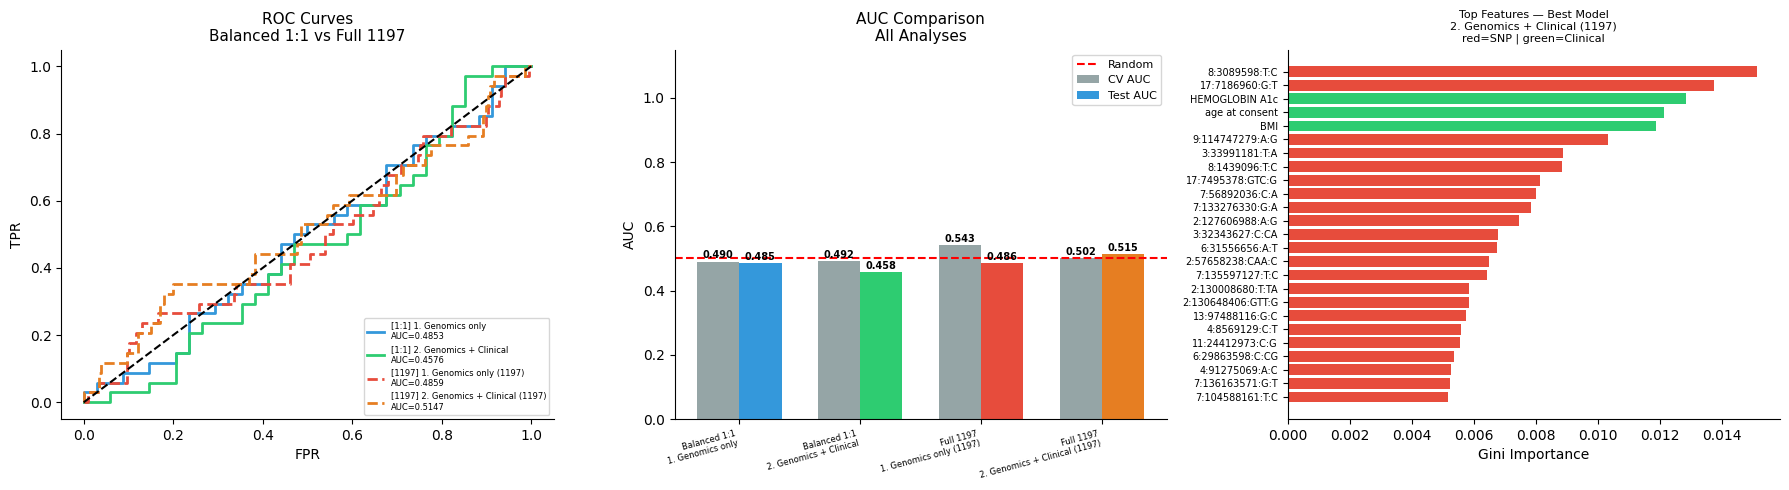


   ALL ANALYSES COMPLETE


,Analysis,Feature Set,N Features,CV AUC,CV AUC std,Test AUC,CV-Test Gap,N Samples,N Cases,N Controls
0,Balanced 1:1,1. Genomics only,479,0.4899,0.0632,0.4853,0.0047,340,170,170
1,Balanced 1:1,2. Genomics + Clinical,483,0.4917,0.0658,0.4576,0.0341,340,170,170
2,Full 1197,1. Genomics only (1197),479,0.5427,0.0641,0.4859,0.0568,1198,170,1028
3,Full 1197,2. Genomics + Clinical (1197),483,0.5019,0.0646,0.5147,-0.0128,1198,170,1028


In [1]:
import os, warnings, sys, subprocess
from pathlib import Path

for pkg in ['pandas','numpy','scipy','scikit-learn','matplotlib','seaborn','openpyxl','imbalanced-learn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'])
print(' Packages ready')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from imblearn.ensemble import BalancedRandomForestClassifier
warnings.filterwarnings('ignore')
%matplotlib inline

BASE       = Path(os.getcwd())
OUT        = BASE / 'gwas_output'
OUT.mkdir(exist_ok=True)
SNP_CSV    = BASE / 'summary_results sorted by p (1).csv'
PHENO_XLSX = BASE / 'final_merged_cleaned.xlsx'
CASES_TXT  = BASE / 'ID_gsd_172cases.txt'
CTRLS_TXT  = BASE / 'ID_gsd_1032controls.txt'

# ── IID2 date fix ─────────────────────────────────────────────────────────────
def fix_iid2(val):
    if pd.isna(val): return val
    val = str(val).strip()
    if val.startswith('2025-') and ('00:00:00' in val or len(val)==10):
        try:
            parts = val.replace(' 00:00:00','').split('-')
            return f'{parts[2]}-{parts[1]}'
        except: return val
    return val

# ── Load SNPs ─────────────────────────────────────────────────────────────────
snp_raw = pd.read_csv(SNP_CSV)
snp_raw = snp_raw[snp_raw['MinP'] <= 1e-5]
snp_df  = (snp_raw[['Gene','TopSNP','MinP']]
           .sort_values('MinP')
           .drop_duplicates(subset='TopSNP')
           .reset_index(drop=True))
print(f' SNPs: {len(snp_df)}')

# ── Load genotype ─────────────────────────────────────────────────────────────
def load_raw(raw_path, snp_list):
    header  = pd.read_csv(raw_path, sep=r'\s+', nrows=0)
    snp_set = set(snp_list)
    col_map = {c: c.rsplit('_',1)[0] for c in header.columns
               if c.rsplit('_',1)[0] in snp_set}
    if not col_map: return pd.DataFrame()
    df = pd.read_csv(raw_path, sep=r'\s+',
                     usecols=['IID']+list(col_map), low_memory=False)
    df.rename(columns=col_map, inplace=True)
    df['IID'] = df['IID'].astype(str)
    print(f'  {raw_path.name}: {len(col_map)} SNPs')
    return df

raw_files = sorted(BASE.glob('*_region.raw'))
gene_map  = {f.stem.replace('_region','').strip('_').upper(): f for f in raw_files}
gene_snps = snp_df.groupby('Gene')['TopSNP'].apply(list).to_dict()

print('\nLoading genotype...')
frames = []
for gene, snps in gene_snps.items():
    g    = gene.upper().strip()
    path = gene_map.get(g)
    if path is None:
        matches = [k for k in gene_map if k.startswith(g) or g.startswith(k)]
        path = gene_map[matches[0]] if matches else None
    if path is None: continue
    chunk = load_raw(path, snps)
    if not chunk.empty: frames.append(chunk)

geno = frames[0]
for f in frames[1:]:
    geno = pd.merge(geno, f, on='IID', how='outer')
geno = geno.loc[:, ~geno.columns.duplicated()]
print(f' Full genotype: {geno.shape}')

# ── Load phenotype ────────────────────────────────────────────────────────────
pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno = pheno.apply(lambda col: col.map(
    lambda x: x.strip() if isinstance(x, str) else x))
pheno.columns = pheno.columns.str.replace('\n',' ').str.strip()
pheno['IID2'] = pheno['IID2'].apply(fix_iid2)

non_feat  = ['External_ID_x','External_ID','sampid','FID','IID','FID2',
             'IID2','SAMPLEID','gall','dys','Unnamed: 16']
pc_cols   = ['PC1','PC2','PC3','PC4']
clin_cols = ['age at consent','Gender','BMI','HEMOGLOBIN A1c']
meta_cols = [c for c in pheno.columns
             if c not in non_feat+pc_cols+clin_cols
             and not c.startswith('PC')
             and not c.startswith('Unnamed')
             and c != 'label']

if 'Gender' in pheno.columns:
    pheno['Gender'] = LabelEncoder().fit_transform(pheno['Gender'].fillna('Unknown'))
for col in clin_cols + pc_cols + meta_cols:
    if col in pheno.columns:
        pheno[col] = pd.to_numeric(pheno[col], errors='coerce')

pheno['gall']  = pheno['gall'].str.lower()
pheno          = pheno[pheno['gall'].isin({'yes','no'})].copy()
pheno['label'] = (pheno['gall']=='yes').astype(int)
pheno['IID2']  = pheno['IID2'].astype(str)

available_clin = [c for c in clin_cols if c in pheno.columns]
available_meta = [c for c in meta_cols if c in pheno.columns]
available_pcs  = [c for c in pc_cols   if c in pheno.columns]

print(f' Phenotype: {len(pheno)} | Cases: {pheno["label"].sum()} | Controls: {(pheno["label"]==0).sum()}')

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 1 — Balanced 1:1 dataset (~170 cases + ~170 controls)
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('ANALYSIS 1 — Balanced 1:1 Dataset')
print('='*60)

# Load matched IDs
cases_ids = pd.read_csv(CASES_TXT, sep=' ', dtype=str)
ctrl_ids  = pd.read_csv(CTRLS_TXT, sep=' ', dtype=str)
case_iids = cases_ids['IID'].str.strip().tolist()
ctrl_iids = ctrl_ids['IID'].str.strip().tolist()

# Get all case IIDs
case_pheno = pheno[pheno['IID2'].isin(case_iids)].copy()
print(f'Cases found: {len(case_pheno)}')

# Randomly sample equal number of controls
np.random.seed(42)
ctrl_pheno = pheno[pheno['IID2'].isin(ctrl_iids) & (pheno['label']==0)].copy()
n_cases    = len(case_pheno)
ctrl_sampled = ctrl_pheno.sample(n=min(n_cases, len(ctrl_pheno)), random_state=42)
balanced_pheno = pd.concat([case_pheno, ctrl_sampled]).reset_index(drop=True)

print(f'Balanced dataset: {len(balanced_pheno)} | Cases: {balanced_pheno["label"].sum()} | Controls: {(balanced_pheno["label"]==0).sum()}')

# Merge with genotype
balanced_iids = set(balanced_pheno['IID2'].tolist())
geno_bal      = geno[geno['IID'].isin(balanced_iids)].copy()
keep_cols     = ['IID2','gall','label'] + available_clin
keep_cols     = [c for c in keep_cols if c in balanced_pheno.columns]

merged_bal = pd.merge(geno_bal,
                      balanced_pheno[keep_cols],
                      left_on='IID', right_on='IID2', how='inner')
snp_cols_bal   = [c for c in merged_bal.columns if c in set(geno.columns)-{'IID'}]
merged_bal['label'] = merged_bal['label'].astype(int)

print(f'Merged balanced: {merged_bal.shape} | Cases: {merged_bal["label"].sum()} | Controls: {(merged_bal["label"]==0).sum()}')
merged_bal.to_csv(OUT/'balanced_1to1_dataset.csv', index=False)

# Train on balanced dataset — 3 feature sets
feature_sets_bal = {
    '1. Genomics only'                      : snp_cols_bal,
    '2. Genomics + Clinical'                : snp_cols_bal + available_clin,
}

cv             = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_bal    = []
trained_bal    = {}

for name, feat_cols in feature_sets_bal.items():
    print(f'\nTraining: {name} ...')
    X = SimpleImputer(strategy='median').fit_transform(
        merged_bal[feat_cols].apply(pd.to_numeric, errors='coerce'))
    y = merged_bal['label'].astype(int).values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)

    model = BalancedRandomForestClassifier(
        n_estimators=200, max_depth=6,
        random_state=42, n_jobs=-1,
        sampling_strategy='auto', replacement=True)

    cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:,1]

    prec,rec,thr = precision_recall_curve(y_te, y_prob)
    f1s         = 2*prec*rec/(prec+rec+1e-8)
    best_thresh = thr[np.argmax(f1s)]
    y_pred      = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_te, y_prob)
    acc = accuracy_score(y_te, y_pred)

    print(f'   CV AUC: {cv_auc.mean():.4f} | Test AUC: {auc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Control','Case']))
   

    trained_bal[name] = (model, auc, y_prob, y_pred, feat_cols, y_te)
    results_bal.append({
        'Analysis'    : 'Balanced 1:1',
        'Feature Set' : name,
        'N Features'  : len(feat_cols),
        'CV AUC'      : round(cv_auc.mean(), 4),
        'CV AUC std'  : round(cv_auc.std(),  4),
        'Test AUC'    : round(auc, 4),
        'CV-Test Gap' : round(cv_auc.mean()-auc, 4),
        'N Samples'   : len(merged_bal),
        'N Cases'     : int(y.sum()),
        'N Controls'  : int((y==0).sum()),
    })

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 2 — Bootstrap on full 1197 samples (Genomics only)
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('ANALYSIS 2 — Bootstrap RF on Full 1197 Samples (Genomics only)')
print('='*60)

all_iids  = set(case_iids + ctrl_iids)
pheno_full= pheno[pheno['IID2'].isin(all_iids)].copy()
geno_full = geno[geno['IID'].isin(all_iids)].copy()

merged_full = pd.merge(geno_full,
                       pheno_full[['IID2','gall','label']+available_clin],
                       left_on='IID', right_on='IID2', how='inner')
snp_cols_full       = [c for c in merged_full.columns if c in set(geno.columns)-{'IID'}]
merged_full['label']= merged_full['label'].astype(int)

print(f'Full dataset: {merged_full.shape} | Cases: {merged_full["label"].sum()} | Controls: {(merged_full["label"]==0).sum()}')

feature_sets_full = {
    '1. Genomics only (1197)'         : snp_cols_full,
    '2. Genomics + Clinical (1197)'   : snp_cols_full + available_clin,
}

results_full = []
trained_full = {}

for name, feat_cols in feature_sets_full.items():
    print(f'\nTraining: {name} ...')
    X = SimpleImputer(strategy='median').fit_transform(
        merged_full[feat_cols].apply(pd.to_numeric, errors='coerce'))
    y = merged_full['label'].astype(int).values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)

    model = BalancedRandomForestClassifier(
        n_estimators=200, max_depth=6,
        random_state=42, n_jobs=-1,
        sampling_strategy='auto', replacement=True)

    cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:,1]

    prec,rec,thr = precision_recall_curve(y_te, y_prob)
    f1s         = 2*prec*rec/(prec+rec+1e-8)
    best_thresh = thr[np.argmax(f1s)]
    y_pred      = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_te, y_prob)
    acc = accuracy_score(y_te, y_pred)

    print(f'   CV AUC: {cv_auc.mean():.4f} | Test AUC: {auc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Control','Case']))

    trained_full[name] = (model, auc, y_prob, y_pred, feat_cols, y_te)
    results_full.append({
        'Analysis'    : 'Full 1197',
        'Feature Set' : name,
        'N Features'  : len(feat_cols),
        'CV AUC'      : round(cv_auc.mean(), 4),
        'CV AUC std'  : round(cv_auc.std(),  4),
        'Test AUC'    : round(auc, 4),
        'CV-Test Gap' : round(cv_auc.mean()-auc, 4),
        'N Samples'   : len(merged_full),
        'N Cases'     : int(y.sum()),
        'N Controls'  : int((y==0).sum()),
    })

# ═══════════════════════════════════════════════════════════════════════════════
# PLOTS — Compare all analyses
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_bal  = ['#3498db','#2ecc71']
colors_full = ['#e74c3c','#e67e22']

# ROC curves — Balanced 1:1
for (name,(model,auc,y_prob,_,_,y_te)),color in zip(trained_bal.items(),colors_bal):
    fpr,tpr,_ = roc_curve(y_te, y_prob)
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f'[1:1] {name}\nAUC={auc:.4f}')

# ROC curves — Full 1197
for (name,(model,auc,y_prob,_,_,y_te)),color in zip(trained_full.items(),colors_full):
    fpr,tpr,_ = roc_curve(y_te, y_prob)
    axes[0].plot(fpr, tpr, lw=2, color=color, linestyle='--',
                 label=f'[1197] {name}\nAUC={auc:.4f}')

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves\nBalanced 1:1 vs Full 1197', fontsize=11)
axes[0].legend(fontsize=6, loc='lower right')
axes[0].spines[['top','right']].set_visible(False)

# AUC comparison bar chart
all_results = results_bal + results_full
names_s     = [f'{r["Analysis"]}\n{r["Feature Set"]}' for r in all_results]
aucs_all    = [r['Test AUC'] for r in all_results]
cv_aucs_all = [r['CV AUC']   for r in all_results]
x = np.arange(len(names_s)); w = 0.35
axes[1].bar(x-w/2, cv_aucs_all, w, label='CV AUC',   color='#95a5a6')
axes[1].bar(x+w/2, aucs_all,    w, label='Test AUC',
            color=colors_bal+colors_full)
for i,(cv,te) in enumerate(zip(cv_aucs_all,aucs_all)):
    axes[1].text(i-w/2, cv+0.01, f'{cv:.3f}', ha='center', fontsize=7, fontweight='bold')
    axes[1].text(i+w/2, te+0.01, f'{te:.3f}', ha='center', fontsize=7, fontweight='bold')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names_s, fontsize=6, rotation=15, ha='right')
axes[1].set_ylabel('AUC'); axes[1].set_ylim(0, 1.15)
axes[1].set_title('AUC Comparison\nAll Analyses', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

# Feature importance — best model overall
all_trained = {**trained_bal, **trained_full}
best_name   = max(all_trained, key=lambda x: all_trained[x][1])
best_model,best_auc,_,_,best_feats,_ = all_trained[best_name]
imp   = best_model.feature_importances_
top_n = min(25, len(best_feats))
idx   = np.argsort(imp)[::-1][:top_n]
cb    = ['#e74c3c' if ':' in best_feats[i] else '#2ecc71' for i in idx]
axes[2].barh(range(top_n), imp[idx][::-1], color=cb[::-1])
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels([best_feats[i] for i in idx][::-1], fontsize=7)
axes[2].set_xlabel('Gini Importance')
axes[2].set_title(f'Top Features — Best Model\n{best_name}\nred=SNP | green=Clinical',
                  fontsize=8)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT/'all_analyses_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save all results ──────────────────────────────────────────────────────────
final_df = pd.DataFrame(all_results)
final_df.to_csv(OUT/'all_analyses_results.csv', index=False)

print('\n'+'='*65)
print('   ALL ANALYSES COMPLETE')
print('='*65)
display(final_df)

 Packages ready
 Phenotype loaded: 3700
   Cases with metabolites   : 100
   Cases without metabolites: 72
   Controls with metabolites: 210

 Combined dataset built:
   Total    : 340
   Cases    : 170
   Controls : 170
   Controls WITH metabolites   : 79
   Controls WITHOUT metabolites: 91
   Cases WITH metabolites      : 98
   Cases WITHOUT metabolites   : 72

 SNPs: 479

Loading genotype...
  CDHR3_region.raw: 36 SNPs
  CLDN7_region.raw: 41 SNPs
  CPZ_region.raw: 51 SNPs
  ERICH1_region.raw: 42 SNPs
  EXOC4_region.raw: 39 SNPs
  GALNTL6_region.raw: 44 SNPs
  GPC6_region.raw: 33 SNPs
  GPRIN3_region.raw: 13 SNPs
  HLA-G_region.raw: 19 SNPs
  HMGB1P5_region.raw: 16 SNPs
  LINC01122_region.raw: 10 SNPs
  LRP8_region.raw: 13 SNPs
  LUZP2_region.raw: 16 SNPs
  MATN2_region.raw: 11 SNPs
  OSBPL10_region.raw: 18 SNPs
  PALM2AKAP2_region.raw: 8 SNPs
  PTPRN2_region.raw: 14 SNPs
  RNFT2_region.raw: 19 SNPs
  RPL31P35_region.raw: 10 SNPs
  TJP1_region.raw: 9 SNPs
  UGGT1_region.raw: 17 SNPs


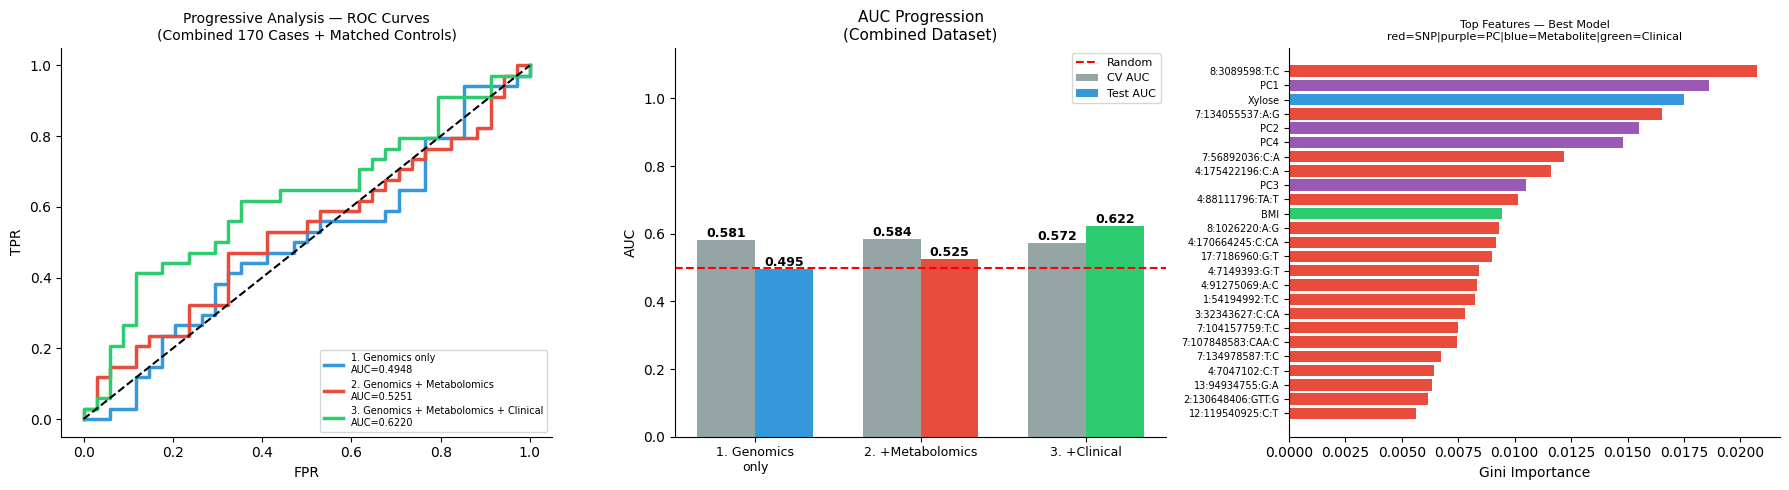

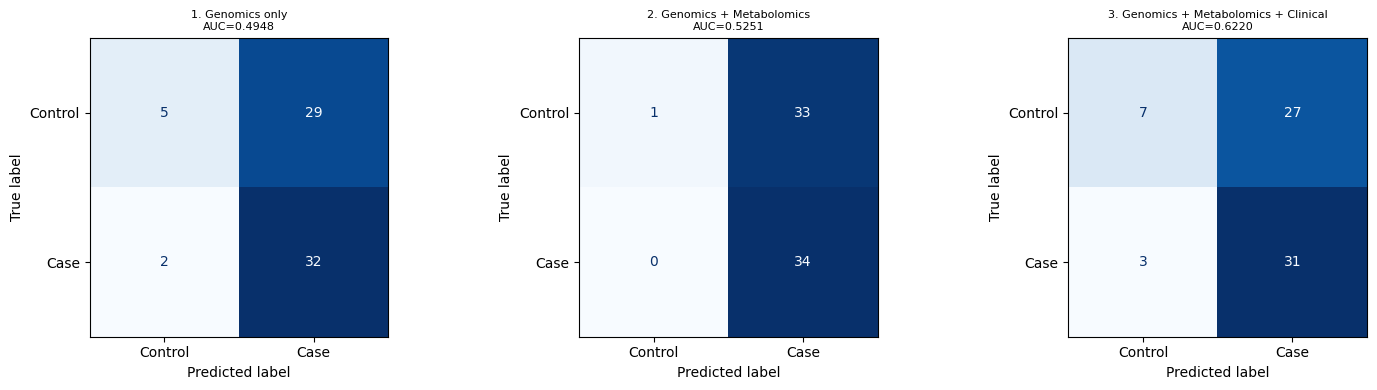


   COMPLETE — Combined 170 Cases + Matched Controls
  Total samples : 340
  Cases         : 170
  Controls      : 170


,Feature Set,N Features,CV AUC,CV AUC std,Test AUC,CV-Test Gap,N Samples,N Cases,N Controls
0,1. Genomics only,479,0.5811,0.0413,0.4948,0.0863,340,170,170
1,2. Genomics + Metabolomics,785,0.5842,0.0672,0.5251,0.0591,340,170,170
2,3. Genomics + Metabolomics + Clinical,789,0.5717,0.0744,0.6220,-0.0503,340,170,170


In [2]:
import os, warnings, sys, subprocess
from pathlib import Path

for pkg in ['pandas','numpy','scipy','scikit-learn','matplotlib','seaborn','openpyxl','imbalanced-learn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'])
print(' Packages ready')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from imblearn.ensemble import BalancedRandomForestClassifier
warnings.filterwarnings('ignore')
%matplotlib inline

BASE       = Path(os.getcwd())
OUT        = BASE / 'gwas_output'
OUT.mkdir(exist_ok=True)
SNP_CSV    = BASE / 'summary_results sorted by p (1).csv'
PHENO_XLSX = BASE / 'final_merged_cleaned.xlsx'
CASES_TXT  = BASE / 'ID_gsd_172cases.txt'
CTRLS_TXT  = BASE / 'ID_gsd_1032controls.txt'

# ── IID2 date fix ─────────────────────────────────────────────────────────────
def fix_iid2(val):
    if pd.isna(val): return val
    val = str(val).strip()
    if val.startswith('2025-') and ('00:00:00' in val or len(val)==10):
        try:
            parts = val.replace(' 00:00:00','').split('-')
            return f'{parts[2]}-{parts[1]}'
        except: return val
    return val

# ── Load phenotype ────────────────────────────────────────────────────────────
pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno = pheno.apply(lambda col: col.map(
    lambda x: x.strip() if isinstance(x, str) else x))
pheno.columns = pheno.columns.str.replace('\n',' ').str.strip()
pheno['IID2'] = pheno['IID2'].apply(fix_iid2)
pheno['gall']  = pheno['gall'].str.lower()
pheno          = pheno[pheno['gall'].isin({'yes','no'})].copy()
pheno['label'] = (pheno['gall']=='yes').astype(int)
pheno['IID2']  = pheno['IID2'].astype(str)
pheno['has_metabolites'] = pheno['SAMPLEID'].notna() & (pheno['SAMPLEID'].str.strip() != '')

# Feature columns
non_feat  = ['External_ID_x','External_ID','sampid','FID','IID','FID2',
             'IID2','SAMPLEID','gall','dys','Unnamed: 16','has_metabolites']
pc_cols   = ['PC1','PC2','PC3','PC4']
clin_cols = ['age at consent','Gender','BMI','HEMOGLOBIN A1c']
meta_cols = [c for c in pheno.columns
             if c not in non_feat+pc_cols+clin_cols
             and not c.startswith('PC')
             and not c.startswith('Unnamed')
             and c != 'label']

if 'Gender' in pheno.columns:
    pheno['Gender'] = LabelEncoder().fit_transform(pheno['Gender'].fillna('Unknown'))
for col in clin_cols + pc_cols + meta_cols:
    if col in pheno.columns:
        pheno[col] = pd.to_numeric(pheno[col], errors='coerce')

available_clin = [c for c in clin_cols if c in pheno.columns]
available_meta = [c for c in meta_cols if c in pheno.columns]
available_pcs  = [c for c in pc_cols   if c in pheno.columns]

print(f' Phenotype loaded: {len(pheno)}')
print(f'   Cases with metabolites   : {pheno[(pheno["label"]==1) & pheno["has_metabolites"]].shape[0]}')
print(f'   Cases without metabolites: {pheno[(pheno["label"]==1) & ~pheno["has_metabolites"]].shape[0]}')
print(f'   Controls with metabolites: {pheno[(pheno["label"]==0) & pheno["has_metabolites"]].shape[0]}')

# ── STEP 1: Build combined 170 cases + matched controls ───────────────────────
# Load professor matched IDs
cases_ids  = pd.read_csv(CASES_TXT, sep=' ', dtype=str)
ctrl_ids   = pd.read_csv(CTRLS_TXT, sep=' ', dtype=str)
case_iids  = set(cases_ids['IID'].str.strip().tolist())
ctrl_iids  = set(ctrl_ids['IID'].str.strip().tolist())

# All 170 cases (matched by professor)
all_cases  = pheno[(pheno['IID2'].isin(case_iids)) & (pheno['label']==1)].copy()

# Priority controls:
# 1. First use controls WITH metabolites (same as Khadijah)
# 2. Then fill remaining from matched controls without metabolites
ctrl_with_meta    = pheno[(pheno['IID2'].isin(ctrl_iids)) &
                           (pheno['label']==0) &
                           pheno['has_metabolites']].copy()
ctrl_without_meta = pheno[(pheno['IID2'].isin(ctrl_iids)) &
                           (pheno['label']==0) &
                           ~pheno['has_metabolites']].copy()

n_cases    = len(all_cases)
n_ctrl_meta= len(ctrl_with_meta)
n_needed   = n_cases  # want 1:1 ratio

# Take all controls with metabolites first, then fill up
np.random.seed(42)
if n_ctrl_meta >= n_needed:
    ctrl_selected = ctrl_with_meta.sample(n=n_needed, random_state=42)
else:
    n_extra       = n_needed - n_ctrl_meta
    ctrl_extra    = ctrl_without_meta.sample(
        n=min(n_extra, len(ctrl_without_meta)), random_state=42)
    ctrl_selected = pd.concat([ctrl_with_meta, ctrl_extra])

combined_pheno = pd.concat([all_cases, ctrl_selected]).reset_index(drop=True)

print(f'\n Combined dataset built:')
print(f'   Total    : {len(combined_pheno)}')
print(f'   Cases    : {combined_pheno["label"].sum()}')
print(f'   Controls : {(combined_pheno["label"]==0).sum()}')
print(f'   Controls WITH metabolites   : {combined_pheno[(combined_pheno["label"]==0) & combined_pheno["has_metabolites"]].shape[0]}')
print(f'   Controls WITHOUT metabolites: {combined_pheno[(combined_pheno["label"]==0) & ~combined_pheno["has_metabolites"]].shape[0]}')
print(f'   Cases WITH metabolites      : {combined_pheno[(combined_pheno["label"]==1) & combined_pheno["has_metabolites"]].shape[0]}')
print(f'   Cases WITHOUT metabolites   : {combined_pheno[(combined_pheno["label"]==1) & ~combined_pheno["has_metabolites"]].shape[0]}')

# ── STEP 2: Load SNPs ─────────────────────────────────────────────────────────
snp_raw = pd.read_csv(SNP_CSV)
snp_raw = snp_raw[snp_raw['MinP'] <= 1e-5]
snp_df  = (snp_raw[['Gene','TopSNP','MinP']]
           .sort_values('MinP')
           .drop_duplicates(subset='TopSNP')
           .reset_index(drop=True))
print(f'\n SNPs: {len(snp_df)}')

# ── STEP 3: Load genotype ─────────────────────────────────────────────────────
def load_raw(raw_path, snp_list):
    header  = pd.read_csv(raw_path, sep=r'\s+', nrows=0)
    snp_set = set(snp_list)
    col_map = {c: c.rsplit('_',1)[0] for c in header.columns
               if c.rsplit('_',1)[0] in snp_set}
    if not col_map: return pd.DataFrame()
    df = pd.read_csv(raw_path, sep=r'\s+',
                     usecols=['IID']+list(col_map), low_memory=False)
    df.rename(columns=col_map, inplace=True)
    df['IID'] = df['IID'].astype(str)
    print(f'  {raw_path.name}: {len(col_map)} SNPs')
    return df

raw_files = sorted(BASE.glob('*_region.raw'))
gene_map  = {f.stem.replace('_region','').strip('_').upper(): f for f in raw_files}
gene_snps = snp_df.groupby('Gene')['TopSNP'].apply(list).to_dict()
combined_iids = set(combined_pheno['IID2'].tolist())

print('\nLoading genotype...')
frames = []
for gene, snps in gene_snps.items():
    g    = gene.upper().strip()
    path = gene_map.get(g)
    if path is None:
        matches = [k for k in gene_map if k.startswith(g) or g.startswith(k)]
        path = gene_map[matches[0]] if matches else None
    if path is None: continue
    chunk = load_raw(path, snps)
    if not chunk.empty: frames.append(chunk)

geno = frames[0]
for f in frames[1:]:
    geno = pd.merge(geno, f, on='IID', how='outer')
geno          = geno.loc[:, ~geno.columns.duplicated()]
geno_filtered = geno[geno['IID'].isin(combined_iids)].copy()
print(f'\n Genotype filtered: {geno_filtered.shape}')

# ── STEP 4: Merge ─────────────────────────────────────────────────────────────
keep = (['IID2','gall','label','has_metabolites'] +
        available_pcs + available_clin + available_meta)
keep = [c for c in keep if c in combined_pheno.columns]

merged = pd.merge(geno_filtered,
                  combined_pheno[keep],
                  left_on='IID', right_on='IID2', how='inner')

snp_cols        = [c for c in merged.columns if c in set(geno.columns)-{'IID'}]
merged['label'] = merged['label'].astype(int)
print(f'\n Final merged: {merged.shape}') 
print(f'   Cases   : {merged["label"].sum()}')
print(f'   Controls: {(merged["label"]==0).sum()}')
merged.to_csv(OUT/'combined_170_dataset.csv', index=False)

# ── STEP 5: Progressive feature sets ─────────────────────────────────────────
feature_sets = {
    '1. Genomics only'                      : snp_cols,
    '2. Genomics + Metabolomics'            : snp_cols + available_pcs + available_meta,
    '3. Genomics + Metabolomics + Clinical' : snp_cols + available_pcs + available_meta + available_clin,
}

print('\n Feature sets:')
for name, cols in feature_sets.items():
    print(f'   {name}: {len(cols)} features')

# ── STEP 6: Train ─────────────────────────────────────────────────────────────
cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []
trained      = {}

for name, feat_cols in feature_sets.items():
    print(f'\nTraining: {name} ...')
    X = SimpleImputer(strategy='median').fit_transform(
        merged[feat_cols].apply(pd.to_numeric, errors='coerce'))
    y = merged['label'].astype(int).values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)

    model = BalancedRandomForestClassifier(
        n_estimators=200, max_depth=6,
        random_state=42, n_jobs=-1,
        sampling_strategy='auto', replacement=True)

    cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:,1]

    prec,rec,thr = precision_recall_curve(y_te, y_prob)
    f1s         = 2*prec*rec/(prec+rec+1e-8)
    best_thresh = thr[np.argmax(f1s)]
    y_pred      = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_te, y_prob)
    acc = accuracy_score(y_te, y_pred)

    print(f'   CV AUC : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')
    print(f'   Test AUC: {auc:.4f} | Accuracy: {acc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Control','Case']))

    trained[name] = (model, auc, y_prob, y_pred, feat_cols, y_te)
    results_list.append({
        'Feature Set' : name,
        'N Features'  : len(feat_cols),
        'CV AUC'      : round(cv_auc.mean(), 4),
        'CV AUC std'  : round(cv_auc.std(),  4),
        'Test AUC'    : round(auc, 4),
        'CV-Test Gap' : round(cv_auc.mean()-auc, 4),
        'N Samples'   : len(merged),
        'N Cases'     : int(y.sum()),
        'N Controls'  : int((y==0).sum()),
    })

# ── STEP 7: Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db','#e74c3c','#2ecc71']

for (name,(model,auc,y_prob,_,_,y_te)),color in zip(trained.items(),colors):
    fpr,tpr,_ = roc_curve(y_te, y_prob)
    axes[0].plot(fpr, tpr, lw=2.5, color=color,
                 label=f'{name}\nAUC={auc:.4f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Progressive Analysis — ROC Curves\n(Combined 170 Cases + Matched Controls)',
                  fontsize=10)
axes[0].legend(fontsize=7, loc='lower right')
axes[0].spines[['top','right']].set_visible(False)

names_s  = ['1. Genomics\nonly','2. +Metabolomics','3. +Clinical']
aucs     = [r['Test AUC'] for r in results_list]
cv_aucs  = [r['CV AUC']   for r in results_list]
x = np.arange(3); w = 0.35
axes[1].bar(x-w/2, cv_aucs, w, label='CV AUC',   color='#95a5a6')
axes[1].bar(x+w/2, aucs,    w, label='Test AUC', color=colors)
for i,(cv,te) in enumerate(zip(cv_aucs,aucs)):
    axes[1].text(i-w/2, cv+0.01, f'{cv:.3f}', ha='center',
                 fontsize=9, fontweight='bold')
    axes[1].text(i+w/2, te+0.01, f'{te:.3f}', ha='center',
                 fontsize=9, fontweight='bold')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random')
axes[1].set_xticks(x); axes[1].set_xticklabels(names_s, fontsize=9)
axes[1].set_ylabel('AUC'); axes[1].set_ylim(0, 1.15)
axes[1].set_title('AUC Progression\n(Combined Dataset)', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

best_name = max(trained, key=lambda x: trained[x][1])
best_model,best_auc,_,_,best_feats,_ = trained[best_name]
imp   = best_model.feature_importances_
top_n = min(25, len(best_feats))
idx   = np.argsort(imp)[::-1][:top_n]
cb    = ['#e74c3c' if best_feats[i] in snp_cols
         else '#9b59b6' if best_feats[i] in available_pcs
         else '#3498db' if best_feats[i] in available_meta
         else '#2ecc71' for i in idx]
axes[2].barh(range(top_n), imp[idx][::-1], color=cb[::-1])
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels([best_feats[i] for i in idx][::-1], fontsize=7)
axes[2].set_xlabel('Gini Importance')
axes[2].set_title('Top Features — Best Model\nred=SNP|purple=PC|blue=Metabolite|green=Clinical',
                  fontsize=8)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT/'combined_170_progressive.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i,(name,(model,auc,y_prob,y_pred,_,y_te)) in enumerate(trained.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=['Control','Case']
    ).plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAUC={auc:.4f}', fontsize=8)
plt.tight_layout()
plt.savefig(OUT/'combined_170_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ── STEP 8: Save ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_list)
results_df.to_csv(OUT/'combined_170_results.csv', index=False)

print('\n'+'='*65)
print('   COMPLETE — Combined 170 Cases + Matched Controls')
print(f'  Total samples : {len(merged)}')
print(f'  Cases         : {merged["label"].sum()}')
print(f'  Controls      : {(merged["label"]==0).sum()}')
print('='*65)
display(results_df)